# TRM — Puzzle-ID Collapsing: Baseline vs. Collapsed Comparison (ARC-AGI-2)

Fetches the pretrained `arc_v2_public` checkpoint, builds a per-augmentation-ID dataset and an ID-collapsed dataset for ARC-AGI-2 tasks, and compares the checkpoint's predictions under both puzzle-ID schemes. The collapsed dataset's initial embeddings are the average of the checkpoint's own trained per-task augmentation embeddings.

## 0. Config

In [1]:
import os

CFG = dict(
    repo_dir       = "/kaggle/working/TinyRecursiveModels",
    dsl_dir        = "/kaggle/working/arc-dsl",
    ckpt_repo_id   = "arcprize/trm_arc_prize_verification",
    ckpt_dest      = "checkpoints/hf_trm",
    num_aug        = 1000,
)
os.makedirs("/kaggle/working", exist_ok=True)


## 1. Environment setup

In [2]:
%%bash
cd /kaggle/working
if [ ! -d TinyRecursiveModels ]; then
    git clone https://github.com/AntonioRoye/TinyRecursiveModels.git
fi
if [ ! -d arc-dsl ]; then
    git clone https://github.com/michaelhodel/arc-dsl.git
fi
cd TinyRecursiveModels

pip install -q --upgrade pip wheel setuptools
# Pinned to a fixed stable release rather than a nightly build, so the environment
# is reproducible across runs.
pip install -q torch==2.11.0 torchvision==0.26.0 torchaudio==2.11.0 --index-url https://download.pytorch.org/whl/cu126
pip install -q -r requirements.txt || echo "[non-fatal] one or more requirements.txt lines failed (expected: adam-atan2) -- continuing"
pip install -q huggingface_hub argdantic pandas matplotlib

echo "--- torch / CUDA diagnostics ---"
python -c "import torch; print('torch', torch.__version__, '| cuda', torch.version.cuda, '| available', torch.cuda.is_available())"
which nvcc && nvcc --version || echo "nvcc not found on PATH"
echo "--- installing adam-atan2 (must succeed) ---"
set -e
pip install --no-cache-dir --no-build-isolation --force-reinstall adam-atan2
python -c "from adam_atan2 import AdamATan2; print('adam_atan2 import OK, backend built successfully')"
set +e
echo "SETUP_CELL_DONE"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 61.2 MB/s eta 0:00:00
--- torch / CUDA diagnostics ---
torch 2.11.0+cu126 | cuda 12.6 | available True
/usr/local/cuda/bin/nvcc
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
--- installing adam-atan2 (must succeed) ---
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for adam-atan2: filename=adam_atan2-0.0.3-cp312-cp312-linux_x86_64.whl size=207497 sha256=77b725305233881843c2481b2bacee6cbfcc31b7d6845def948d69556aacdc5a
  Stored in directory: /tmp/pip-ephem-wheel-cache-aiaa3l3c/wheels/45/32/31/044d4e2d7dc14d2820c0232d9f41b3ae8cb3d8451451a80dbf
Successfully built adam-atan2
  Attempting uninstall: adam-atan2
    Found e

Cloning into 'TinyRecursiveModels'...
Cloning into 'arc-dsl'...


In [3]:
import sys
sys.path.append(CFG["repo_dir"])
sys.path.append(CFG["dsl_dir"])
os.chdir(CFG["repo_dir"])
print("cwd:", os.getcwd())

# Verify core dependencies imported cleanly before proceeding.
import importlib
required = ["torch", "hydra", "omegaconf", "pydantic", "numpy", "pandas",
            "matplotlib", "huggingface_hub", "argdantic",
            "adam_atan2", "adam_atan2_backend"]
missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
    except ImportError as e:
        missing.append((pkg, str(e)))
if missing:
    for pkg, err in missing:
        print(f"MISSING/BROKEN: {pkg} -> {err}")
    raise RuntimeError(
        "One or more core dependencies failed to import -- see package names above."
    )
print("All core imports OK.")

cwd: /kaggle/working/TinyRecursiveModels
All core imports OK.


## 2. Fetch the pretrained checkpoint

In [4]:

import subprocess
subprocess.run(
    ["python", "-m", "experiments.fetch_hf_checkpoints",
     "--repo_id", CFG["ckpt_repo_id"], "--dest", CFG["ckpt_dest"]],
    check=True,
)

# This HF repo ships both arc_v1_public (ARC-AGI-1) and arc_v2_public (ARC-AGI-2).
import glob
patterns = ["*.pt", "*.pth", "*step_*", "*.bin"]
candidates = []
for pat in patterns:
    candidates.extend(glob.glob(f'{CFG["ckpt_dest"]}/**/{pat}', recursive=True))
candidates = sorted(set(candidates))
assert candidates, f'No checkpoint files found under {CFG["ckpt_dest"]} -- inspect the directory manually.'
print("All candidate checkpoint files found:")
for c in candidates:
    print(" ", c)

# Select the ARC-AGI-2 checkpoint from the discovered candidates.
v2_candidates = [c for c in candidates if "arc_v2_public" in c]
assert v2_candidates, "No arc_v2_public checkpoint found among candidates -- inspect the printed list above."
V2_CKPT_PATH = sorted(v2_candidates)[-1]
print("\nV2_CKPT_PATH:", V2_CKPT_PATH)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Fetching 11 files: 100%|██████████| 11/11 [00:12<00:00,  1.10s/it]


Downloaded to: /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm

Candidate checkpoint files:
- /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/.cache/huggingface/download/arc_v1_public/step_518071.metadata | sha256=defbe248ea7d8915f521bd80598dfccbeb2cab6e88135974e8079a928d8bd29b
- /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/.cache/huggingface/download/arc_v2_public/step_723914.metadata | sha256=9fad1a450cb0640e945a4583752dfd4454728520b81648119c4ab99799821b94
- /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/arc_v1_public/step_518071 | sha256=53689643ad1606d7c22c758f8af0a71b3b66275dea074f214d2f1048d9a01fb0
- /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/arc_v2_public/step_723914 | sha256=8d7036b97e7ea38c7dd29d01216bfcfc4e212af3024d5233fe40dd3059e8f4a9

Use one of the above paths as load_checkpoint=... for experiments.run_exp1
All candidate checkpoint files found:
  checkpoints/hf_trm/arc_v1_public/step_518071
  checkpoints/hf_trm/arc_v2_public/ste

## 3. Dataset utilities

`build_collapsed_dataset` remaps a per-augmentation-ID dataset (from `dataset.build_arc_dataset`) into one canonical ID per task.

In [5]:

import json
import shutil
import numpy as np
from pathlib import Path


def build_collapsed_dataset(src_dir: str, dst_dir: str, splits=("train", "test")):
    '''Remap a per-augmentation-ID ARC dataset (from build_arc_dataset.py) into a
    dataset where every augmented copy of a task shares one canonical puzzle ID.

    Only `all__puzzle_identifiers.npy` and the identifier bookkeeping change.
    Inputs, labels, puzzle_indices and group_indices are copied verbatim, since
    augmentation content/grouping is unaffected by which embedding row is used.
    '''
    src, dst = Path(src_dir), Path(dst_dir)
    dst.mkdir(parents=True, exist_ok=True)

    identifiers = json.loads((src / "identifiers.json").read_text())

    # old_idx -> canonical name (strip "|||aug_idx" if present)
    def canonical_name(name):
        return name.split("|||")[0]

    canonical_names_in_order = []
    seen = set()
    for name in identifiers:
        cname = canonical_name(name)
        if cname not in seen:
            seen.add(cname)
            canonical_names_in_order.append(cname)

    new_id_of_canonical = {name: i for i, name in enumerate(canonical_names_in_order)}
    old_to_new = np.array(
        [new_id_of_canonical[canonical_name(name)] for name in identifiers],
        dtype=np.int64,
    )

    print(f"{src_dir}: {len(identifiers)} identifiers -> {len(canonical_names_in_order)} "
          f"canonical identifiers ({len(identifiers) - len(canonical_names_in_order)} collapsed away)")

    (dst / "identifiers.json").write_text(json.dumps(canonical_names_in_order))

    for split in splits:
        s_split, d_split = src / split, dst / split
        if not s_split.exists():
            continue
        d_split.mkdir(parents=True, exist_ok=True)

        for f in s_split.glob("*"):
            if f.name == "all__puzzle_identifiers.npy":
                continue
            if f.is_file():
                shutil.copy2(f, d_split / f.name)

        old_ids = np.load(s_split / "all__puzzle_identifiers.npy")
        new_ids = old_to_new[old_ids]
        np.save(d_split / "all__puzzle_identifiers.npy", new_ids)

        meta_path = d_split / "dataset.json"
        meta = json.loads(meta_path.read_text())
        meta["num_puzzle_identifiers"] = len(canonical_names_in_order)
        # blank identifier is conventionally row 0 in both old and new indexing
        meta["blank_identifier_id"] = int(old_to_new[meta["blank_identifier_id"]])
        meta_path.write_text(json.dumps(meta))

        print(f"  [{split}] wrote {len(new_ids)} remapped identifiers, "
              f"num_puzzle_identifiers={meta['num_puzzle_identifiers']}")

    return dst



## 4. Model / eval utilities

In [6]:
import os
import torch

# torch.compile wraps the model via create_model() unless DISABLE_COMPILE is set
# (see pretrain.py). Not needed for correctness, only speed. Must be set before
# any create_model() call.
os.environ["DISABLE_COMPILE"] = "1"

from hydra import initialize_config_dir, compose
from experiments.run_expC_puzzle_id import (
    _patch_load_checkpoint, _patch_trm_device_alignment, _init_single_process_dist,
)
from pretrain import load_synced_config, create_dataloader, create_model
from dataset.build_arc_dataset import arc_grid_to_np, np_grid_to_seq_translational_augment
from evaluators.arc import _crop

_patch_load_checkpoint()
_patch_trm_device_alignment()
_init_single_process_dist()


def load_model_for_dataset(data_dir: str, load_checkpoint):
    """Compose config and build a model wired to `data_dir`'s identifier space.

    `arch.*` is read from the checkpoint's own `all_config.yaml` when one ships
    alongside it, rather than assumed to match config/arch/trm.yaml's repo
    defaults -- the arcprize/trm_arc_prize_verification HF repo hosts multiple
    checkpoints (arc_v1_public, arc_v2_public, ...) that do not share one
    architecture.

    If `load_checkpoint`'s puzzle_emb shape doesn't match this dataset's
    num_puzzle_identifiers, pretrain.py's load_checkpoint() re-initializes that
    table by mean-pooling the old table across all rows and broadcasting that
    single mean vector into every row of the new table (see pretrain.py's
    load_checkpoint implementation).
    """
    overrides = [
        f"data_paths=[{data_dir}]",
        f"data_paths_test=[{data_dir}]",
    ]
    if load_checkpoint:
        overrides.append(f"+load_checkpoint={load_checkpoint}")

        ckpt_cfg_path = Path(load_checkpoint).parent / "all_config.yaml"
        if ckpt_cfg_path.exists():
            import yaml
            ckpt_cfg = yaml.safe_load(ckpt_cfg_path.read_text())
            ckpt_arch = ckpt_cfg.get("arch", {})
            l_cycles = ckpt_arch.get("L_cycles")
            h_cycles = ckpt_arch.get("H_cycles")
            l_layers = ckpt_arch.get("L_layers")
            print(f"[arch-check] {ckpt_cfg_path}: L_cycles={l_cycles}, "
                  f"H_cycles={h_cycles}, L_layers={l_layers}")
            if l_cycles is not None:
                overrides.append(f"arch.L_cycles={l_cycles}")
            if h_cycles is not None:
                overrides.append(f"arch.H_cycles={h_cycles}")
            if l_layers is not None:
                overrides.append(f"arch.L_layers={l_layers}")
        else:
            print(f"[arch-check] no all_config.yaml found next to {load_checkpoint} "
                  f"-- using config/arch/trm.yaml defaults.")

    with initialize_config_dir(version_base=None, config_dir=f'{CFG["repo_dir"]}/config'):
        hydra_cfg = compose(config_name="cfg_pretrain", overrides=overrides)

    config = load_synced_config(hydra_cfg, rank=0, world_size=1)

    eval_loader, eval_metadata = create_dataloader(
        config, split="test", test_set_mode=True, epochs_per_iter=1,
        global_batch_size=config.global_batch_size, rank=0, world_size=1,
    )

    # create_model returns (model, optimizers, optimizer_lrs); optimizers are only
    # relevant for actual training and are unused here.
    model, _optimizers, _optimizer_lrs = create_model(config, eval_metadata, rank=0, world_size=1)
    model.eval()
    return model, eval_metadata, config, eval_loader


def grid_to_input_tokens(grid, metadata):
    inp_np = arc_grid_to_np(grid)
    dummy_out = inp_np.copy()
    inp_seq, _ = np_grid_to_seq_translational_augment(inp_np, dummy_out, do_translation=False)
    return torch.tensor(inp_seq, dtype=torch.int32)


def decode_tokens_to_grid(pred_tokens_single):
    pred_np = pred_tokens_single.to(torch.uint8).cpu().numpy()
    cropped = _crop(pred_np)
    if cropped.size == 0 or len(cropped.shape) < 2 or 0 in cropped.shape:
        return [[0]]
    return cropped.tolist()


@torch.inference_mode()
def run_single(model, input_grid, puzzle_id_int, metadata):
    batch = {
        "inputs": grid_to_input_tokens(input_grid, metadata).unsqueeze(0).cuda(),
        "labels": torch.full((1, metadata.seq_len), metadata.ignore_label_id, dtype=torch.int32).cuda(),
        "puzzle_identifiers": torch.tensor([puzzle_id_int], dtype=torch.int32).cuda(),
    }
    carry = model.initial_carry(batch)
    while True:
        carry, _loss, _metrics, preds, all_finish = model(
            carry=carry, batch=batch, return_keys={"preds", "q_halt_logits"}
        )
        if all_finish:
            break
    return decode_tokens_to_grid(preds["preds"][0])


@torch.inference_mode()
def run_batch(model, examples, metadata):
    """Runs a list of (input_grid, puzzle_id_int) pairs as a single batched forward
    call instead of one call per example.

    Note: all_finish requires every row in the batch to halt before the loop exits,
    so one slow-to-halt example makes every other row in its batch run extra steps.
    """
    inputs = torch.stack([grid_to_input_tokens(g, metadata) for g, _pid in examples], dim=0).cuda()
    labels = torch.full((len(examples), metadata.seq_len), metadata.ignore_label_id, dtype=torch.int32).cuda()
    ids = torch.tensor([pid for _g, pid in examples], dtype=torch.int32).cuda()
    batch = {"inputs": inputs, "labels": labels, "puzzle_identifiers": ids}

    carry = model.initial_carry(batch)
    while True:
        carry, _loss, _metrics, preds, all_finish = model(
            carry=carry, batch=batch, return_keys={"preds", "q_halt_logits"}
        )
        if all_finish:
            break
    return [decode_tokens_to_grid(preds["preds"][i]) for i in range(len(examples))]


def cell_accuracy(pred_grid, true_grid):
    """Fraction of matching cells on the true grid's own shape.
    0.0 if shapes mismatch and grids share no comparable region."""
    p = np.array(pred_grid, dtype=np.int64)
    t = np.array(true_grid, dtype=np.int64)
    if p.shape != t.shape:
        h = min(p.shape[0], t.shape[0]); w = min(p.shape[1], t.shape[1])
        if h == 0 or w == 0:
            return 0.0
        return float((p[:h, :w] == t[:h, :w]).mean()) * (h * w) / (t.shape[0] * t.shape[1])
    return float((p == t).mean())


def grid_exact_match(pred_grid, true_grid):
    return int(np.array(pred_grid, dtype=np.int64).tolist() == np.array(true_grid, dtype=np.int64).tolist())


def structural_accuracy(pred_grid, true_grid):
    """Best-case cell accuracy under any bijective recoloring of the predicted
    grid's 0-9 palette. Distinguishes "right structure, wrong color labels" from
    "actually wrong". Uses the Hungarian algorithm to find the best color-to-color
    assignment.
    """
    from scipy.optimize import linear_sum_assignment
    p = np.array(pred_grid, dtype=np.int64)
    t = np.array(true_grid, dtype=np.int64)
    if p.shape != t.shape:
        return 0.0
    overlap = np.zeros((10, 10), dtype=np.int64)
    for i in range(10):
        mask = p == i
        if not mask.any():
            continue
        overlap[i] = np.bincount(t[mask], minlength=10)
    row_ind, col_ind = linear_sum_assignment(-overlap)
    return float(overlap[row_ind, col_ind].sum()) / t.size


In [7]:
# models/layers.py's Attention.forward ends with a rearrange (transpose) followed
# by .view(), which raises a RuntimeError when the attention backend's output isn't
# contiguous in the required layout. Patched here to use .reshape() instead, which
# handles both contiguous and non-contiguous inputs. Must run before the first
# create_model() call.
import importlib
import einops as _einops
from torch.nn.functional import scaled_dot_product_attention as _sdpa


def _patch_attention_view_bug() -> None:
    layers_mod = importlib.import_module("models.layers")

    def _patched_forward(self, cos_sin, hidden_states):
        batch_size, seq_len, _ = hidden_states.shape
        qkv = self.qkv_proj(hidden_states)
        qkv = qkv.view(batch_size, seq_len, self.num_heads + 2 * self.num_key_value_heads, self.head_dim)
        query = qkv[:, :, :self.num_heads]
        key = qkv[:, :, self.num_heads: self.num_heads + self.num_key_value_heads]
        value = qkv[:, :, self.num_heads + self.num_key_value_heads:]

        if cos_sin is not None:
            cos, sin = cos_sin
            query, key = layers_mod.apply_rotary_pos_emb(query, key, cos, sin)

        query, key, value = map(lambda t: _einops.rearrange(t, 'B S H D -> B H S D'), (query, key, value))
        attn_output = _sdpa(query=query, key=key, value=value, is_causal=self.causal)
        attn_output = _einops.rearrange(attn_output, 'B H S D -> B S H D')
        attn_output = attn_output.reshape(batch_size, seq_len, self.output_size)
        return self.o_proj(attn_output)

    layers_mod.Attention.forward = _patched_forward
    print("[patch] models.layers.Attention.forward patched: .view() -> .reshape() after rearrange")


_patch_attention_view_bug()


[patch] models.layers.Attention.forward patched: .view() -> .reshape() after rearrange


## 5. Full-task-set pipeline

Builds the dataset for all ARC-AGI-2 training tasks (`--subsets training2 evaluation2 concept --test-set-name evaluation2`, matching the checkpoint's original training recipe), so `identifiers.json`'s row order matches the checkpoint's own puzzle-embedding table -- confirmed by the identifier count matching the checkpoint's `puzzle_emb` shape. A task's per-augmentation rows can then be read directly out of `identifiers.json` by name.

In [8]:
# Load all ARC-AGI-2 training tasks, with ground truth merged in.
import json as _json
import copy
import random

with open(f'{CFG["repo_dir"]}/kaggle/combined/arc-agi_training2_challenges.json') as f:
    _full_challenges_v2 = _json.load(f)
with open(f'{CFG["repo_dir"]}/kaggle/combined/arc-agi_training2_solutions.json') as f:
    _full_solutions_v2 = _json.load(f)

tasks_v2 = copy.deepcopy(_full_challenges_v2)
for tid, sol in _full_solutions_v2.items():
    if tid in tasks_v2:
        for i, out in enumerate(sol):
            if i < len(tasks_v2[tid]["test"]):
                tasks_v2[tid]["test"][i]["output"] = out

all_task_ids_v2 = list(tasks_v2.keys())
print(f"{len(all_task_ids_v2)} ARC-AGI-2 training tasks loaded with ground truth.")

# Load all ARC-AGI-2 evaluation tasks the same way.
with open(f'{CFG["repo_dir"]}/kaggle/combined/arc-agi_evaluation2_challenges.json') as f:
    _eval2_challenges = _json.load(f)
with open(f'{CFG["repo_dir"]}/kaggle/combined/arc-agi_evaluation2_solutions.json') as f:
    _eval2_solutions = _json.load(f)

tasks_v2_eval = copy.deepcopy(_eval2_challenges)
for tid, sol in _eval2_solutions.items():
    if tid in tasks_v2_eval:
        for i, out in enumerate(sol):
            if i < len(tasks_v2_eval[tid]["test"]):
                tasks_v2_eval[tid]["test"][i]["output"] = out

all_task_ids_v2_eval = list(tasks_v2_eval.keys())
print(f"{len(all_task_ids_v2_eval)} ARC-AGI-2 evaluation tasks loaded with ground truth.")

# Used by the augmentation-transform helpers below.
from dataset.build_arc_dataset import PuzzleIdSeparator, arc_grid_to_np
from dataset.common import dihedral_transform


def parse_aug_name(name: str):
    """Inverse of aug()'s name construction: recovers (trans_id, forward_color_mapping)
    from an augmented identifier string. Returns None for a canonical (un-augmented) name."""
    if PuzzleIdSeparator not in name:
        return None
    _canonical, trans_part, perm_part = name.split(PuzzleIdSeparator)
    trans_id = int(trans_part[1:])
    mapping = np.array([int(c) for c in perm_part], dtype=np.uint8)
    return trans_id, mapping


def apply_named_transform(grid, name: str):
    """Apply the exact transform a row's identifier name encodes."""
    parsed = parse_aug_name(name)
    if parsed is None:
        return np.array(grid, dtype=np.uint8)
    trans_id, mapping = parsed
    return dihedral_transform(mapping[np.array(grid, dtype=np.uint8)], trans_id)


1000 ARC-AGI-2 training tasks loaded with ground truth.
120 ARC-AGI-2 evaluation tasks loaded with ground truth.


## 6. Build the full baseline + collapsed datasets

In [9]:

# Builds via an in-process convert_dataset() call, skipping the input/label arrays
# since only identifier indexing and the embedding table are needed here. Skipped
# if the dataset already exists on disk.
import shutil
import subprocess

v2_baseline_data = "data/v2-full-aug-1000"
v2_collapsed_data = "data/v2-full-aug-1000-collapsed"

if not (Path(v2_baseline_data) / "identifiers.json").exists():
    print("Disk space before cleanup:")
    subprocess.run(["df", "-h", "/kaggle/working"])

    for stale in ["checkpoints/hf_trm/arc_v1_public",
                  "checkpoints/hf_trm/.cache/huggingface/download/arc_v1_public"]:
        p = Path(CFG["repo_dir"]) / stale
        if p.exists():
            shutil.rmtree(p, ignore_errors=True)
            print("Removed", p)

    print("\nDisk space after cleanup:")
    subprocess.run(["df", "-h", "/kaggle/working"])

    from dataset.build_arc_dataset import DataProcessConfig, convert_dataset
    import numpy as _np

    _orig_save = _np.save
    def _skip_big_arrays(file, arr, *a, **kw):
        fname = str(file)
        if fname.endswith("__inputs.npy") or fname.endswith("__labels.npy"):
            return
        return _orig_save(file, arr, *a, **kw)

    _np.save = _skip_big_arrays
    try:
        convert_dataset(DataProcessConfig(
            input_file_prefix="kaggle/combined/arc-agi",
            output_dir=v2_baseline_data,
            subsets=["training2", "evaluation2", "concept"],
            test_set_name="evaluation2",
            num_aug=CFG["num_aug"],
            puzzle_identifiers_start=1,
        ))
    finally:
        _np.save = _orig_save
else:
    print(f"{v2_baseline_data} already exists -- skipping rebuild.")

# The printed "Total puzzle IDs" count is checked against the checkpoint's
# puzzle_emb shape in the next section.
print("\nidentifiers.json present:", (Path(v2_baseline_data) / "identifiers.json").exists())


Disk space before cleanup:
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  4.1G   16G  21% /kaggle/working
Removed /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/arc_v1_public
Removed /kaggle/working/TinyRecursiveModels/checkpoints/hf_trm/.cache/huggingface/download/arc_v1_public

Disk space after cleanup:
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  2.4G   18G  12% /kaggle/working
[Puzzle bd14c3bf] augmentation not full, only 574
[Puzzle 8dab14c2] augmentation not full, only 575
[Puzzle 3aa6fb7a] augmentation not full, only 576
[Puzzle e6de6e8f] augmentation not full, only 576
[Puzzle 5c0a986e] augmentation not full, only 576
[Puzzle 2697da3f] augmentation not full, only 72
[Puzzle 3618c87e] augmentation not full, only 576
[Puzzle 5168d44c] augmentation not full, only 576
[Puzzle 9bebae7a] augmentation not full, only 575
[Puzzle 90f3ed37] augmentation not full, only 576
[Puzzle 1990f7a8] augmentation not full, only 72
[Puzzle 20

In [10]:

if not (Path(v2_collapsed_data) / "identifiers.json").exists():
    build_collapsed_dataset(v2_baseline_data, v2_collapsed_data)
else:
    print(f"{v2_collapsed_data} already exists -- skipping rebuild.")


data/v2-full-aug-1000: 1191730 identifiers -> 1281 canonical identifiers (1190449 collapsed away)
  [train] wrote 1191729 remapped identifiers, num_puzzle_identifiers=1281
  [test] wrote 118766 remapped identifiers, num_puzzle_identifiers=1281


## 7. Load models and set up on-demand, memoized embedding averaging

In [11]:

# Checkpoint's own embedding table -- the source of the averaged vectors below.
sd_v2 = torch.load(V2_CKPT_PATH, map_location="cpu")
if any(isinstance(k, str) and k.startswith("_orig_mod.") for k in sd_v2.keys()):
    sd_v2 = {(k[10:] if k.startswith("_orig_mod.") else k): v for k, v in sd_v2.items()}
ckpt_puzzle_emb_v2 = sd_v2["model.inner.puzzle_emb.weights"]
print("v2 ckpt puzzle_emb shape:", tuple(ckpt_puzzle_emb_v2.shape))

model_v2_baseline, meta_v2_baseline, _, _ = load_model_for_dataset(v2_baseline_data, V2_CKPT_PATH)
assert model_v2_baseline.model.inner.puzzle_emb.weights.shape == ckpt_puzzle_emb_v2.shape, \
    "SHAPE MISMATCH -- still hitting the mean-pool fallback, do not continue past this cell"

model_v2_collapsed, meta_v2_collapsed, _, _ = load_model_for_dataset(v2_collapsed_data, V2_CKPT_PATH)

v2_baseline_ids = _json.loads(Path(v2_baseline_data, "identifiers.json").read_text())
task_to_id_v2_baseline = {name: i for i, name in enumerate(v2_baseline_ids)
                           if PuzzleIdSeparator not in name and name != "<blank>"}

v2_collapsed_ids = _json.loads(Path(v2_collapsed_data, "identifiers.json").read_text())
task_to_id_v2_collapsed = {name: i for i, name in enumerate(v2_collapsed_ids) if name != "<blank>"}

print(f"{len(task_to_id_v2_baseline)} baseline task IDs, {len(task_to_id_v2_collapsed)} collapsed task IDs.")


v2 ckpt puzzle_emb shape: (1191730, 512)
[arch-check] checkpoints/hf_trm/arc_v2_public/all_config.yaml: L_cycles=4, H_cycles=3, L_layers=2
TinyRecursiveReasoningModel_ACTV1(
  (inner): TinyRecursiveReasoningModel_ACTV1_Inner(
    (embed_tokens): CastedEmbedding()
    (lm_head): CastedLinear()
    (q_head): CastedLinear()
    (puzzle_emb): CastedSparseEmbedding()
    (rotary_emb): RotaryEmbedding()
    (L_level): TinyRecursiveReasoningModel_ACTV1ReasoningModule(
      (layers): ModuleList(
        (0-1): 2 x TinyRecursiveReasoningModel_ACTV1Block(
          (self_attn): Attention(
            (qkv_proj): CastedLinear()
            (o_proj): CastedLinear()
          )
          (mlp): SwiGLU(
            (gate_up_proj): CastedLinear()
            (down_proj): CastedLinear()
          )
        )
      )
    )
  )
)
[ExpC] Patched load_checkpoint: checkpoints/hf_trm/arc_v2_public/step_723914
[arch-check] checkpoints/hf_trm/arc_v2_public/all_config.yaml: L_cycles=4, H_cycles=3, L_layers=2


In [12]:

# Cache of averaged embeddings, keyed by task_id -- computed once per task and
# reused by every later compare_tasks_v2() call.
task_averaged_embeddings_v2 = {}


def ensure_collapsed_embedding_v2(task_id: str):
    """Compute (if not already cached) the checkpoint-averaged embedding for
    `task_id` and write it into model_v2_collapsed's row for that task.
    Safe to call repeatedly -- a no-op after the first call for a given task_id."""
    if task_id in task_averaged_embeddings_v2:
        return task_averaged_embeddings_v2[task_id]
    if task_id not in task_to_id_v2_baseline:
        raise KeyError(
            f"'{task_id}' not found in v2_baseline_ids -- check spelling, or that it's in "
            f"the ARC-AGI-2 *training* subset (this notebook only indexed that subset's tasks)."
        )

    task_rows = [i for i, name in enumerate(v2_baseline_ids)
                 if name.split(PuzzleIdSeparator)[0] == task_id]
    avg = ckpt_puzzle_emb_v2[task_rows].mean(dim=0)
    task_averaged_embeddings_v2[task_id] = avg

    collapsed_row = task_to_id_v2_collapsed[task_id]
    weights = model_v2_collapsed.model.inner.puzzle_emb.weights
    with torch.no_grad():
        weights[collapsed_row] = avg.to(weights.dtype).to(weights.device)

    print(f"{task_id}: averaged over {len(task_rows)} rows -> overrode collapsed row {collapsed_row}")
    return avg


## 8. Comparison function

In [13]:

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd

ARC_COLORS = ["#000000","#0074D9","#FF4136","#2ECC40","#FFDC00",
              "#AAAAAA","#F012BE","#FF851B","#7FDBFF","#870C25"]
cmap = mcolors.ListedColormap(ARC_COLORS)
norm = mcolors.BoundaryNorm(list(range(11)), cmap.N)

def show_grid(ax, grid, title):
    grid = np.array(grid)
    h, w = grid.shape
    ax.imshow(grid, cmap=cmap, norm=norm)
    ax.set_title(title, fontsize=9)

    # draw gridlines at cell boundaries
    ax.set_xticks(np.arange(-0.5, w, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, h, 1), minor=True)
    ax.grid(which="minor", color="gray", linewidth=0.5)

    # hide the major tick labels/marks, keep the minor gridlines
    ax.set_xticks([]); ax.set_yticks([])
    ax.tick_params(which="minor", length=0)


@torch.inference_mode()
def compare_tasks_v2(task_ids, n_aug_check=5, show_plots=True, seed=0):
    """Baseline-vs-collapsed comparison for a list of ARC-AGI-2 training-set task IDs.

    For each task:
      1. ensure_collapsed_embedding_v2(task_id) -- computed once, cached.
      2. Every train/test example with ground truth is scored on both models:
         cell accuracy and exact grid match.
      3. Up to n_aug_check augmented rows for the task are also scored -- baseline
         uses that row's own distinct per-augmentation checkpoint embedding;
         collapsed uses the same single averaged row for all of them.
      4. `collapsed_embedding_same_as_first` verifies the collapsed model's embedding
         row stays constant across every call in a task's block.

    Returns one pandas DataFrame (one row per example/augmentation evaluated).
    """
    random.seed(seed)
    rows = []

    for task_id in task_ids:
        ensure_collapsed_embedding_v2(task_id)
        baseline_id = task_to_id_v2_baseline[task_id]
        collapsed_id = task_to_id_v2_collapsed[task_id]
        collapsed_weights = model_v2_collapsed.model.inner.puzzle_emb.weights
        reference_vec = collapsed_weights[collapsed_id].detach().clone()

        # --- canonical (un-augmented) train/test examples ---
        for split_name in ("train", "test"):
            for idx, ex in enumerate(tasks_v2[task_id].get(split_name, [])):
                if "output" not in ex:
                    continue
                pred_baseline = run_single(model_v2_baseline, ex["input"], baseline_id, meta_v2_baseline)
                pred_collapsed = run_single(model_v2_collapsed, ex["input"], collapsed_id, meta_v2_collapsed)
                same_vec = torch.equal(collapsed_weights[collapsed_id], reference_vec)
                rows.append(dict(
                    task_id=task_id, kind="canonical", detail=f"{split_name}[{idx}]",
                    baseline_cell_acc=cell_accuracy(pred_baseline, ex["output"]),
                    baseline_grid_exact=grid_exact_match(pred_baseline, ex["output"]),
                    collapsed_cell_acc=cell_accuracy(pred_collapsed, ex["output"]),
                    collapsed_grid_exact=grid_exact_match(pred_collapsed, ex["output"]),
                    collapsed_embedding_same_as_first=same_vec,
                ))

        # --- sampled real augmented rows ---
        aug_rows = [(i, name) for i, name in enumerate(v2_baseline_ids)
                    if name.startswith(task_id + PuzzleIdSeparator)]
        sampled = random.sample(aug_rows, min(n_aug_check, len(aug_rows)))
        base_ex = tasks_v2[task_id]["train"][0]
        for row_id, row_name in sampled:
            aug_inp = apply_named_transform(base_ex["input"], row_name).tolist()
            aug_out = apply_named_transform(base_ex["output"], row_name).tolist()

            pred_baseline = run_single(model_v2_baseline, aug_inp, row_id, meta_v2_baseline)
            pred_collapsed = run_single(model_v2_collapsed, aug_inp, collapsed_id, meta_v2_collapsed)
            same_vec = torch.equal(collapsed_weights[collapsed_id], reference_vec)

            rows.append(dict(
                task_id=task_id, kind="augmented", detail=row_name,
                baseline_cell_acc=cell_accuracy(pred_baseline, aug_out),
                baseline_grid_exact=grid_exact_match(pred_baseline, aug_out),
                collapsed_cell_acc=cell_accuracy(pred_collapsed, aug_out),
                collapsed_grid_exact=grid_exact_match(pred_collapsed, aug_out),
                collapsed_embedding_same_as_first=same_vec,
            ))

    df = pd.DataFrame(rows)

    print(df.groupby(["task_id", "kind"])[["baseline_cell_acc", "collapsed_cell_acc"]].mean())
    print("\nAll collapsed-embedding-identity checks passed:",
          bool(df["collapsed_embedding_same_as_first"].all()))
    print("Overall -- baseline cell acc:", df.baseline_cell_acc.mean(),
          "| collapsed cell acc:", df.collapsed_cell_acc.mean())

    if show_plots:
        for task_id in task_ids:
            baseline_id = task_to_id_v2_baseline[task_id]
            collapsed_id = task_to_id_v2_collapsed[task_id]
            for split_name in ("train", "test"):
                for idx, ex in enumerate(tasks_v2[task_id].get(split_name, [])):
                    if "output" not in ex:
                        continue
                    pred_baseline = run_single(model_v2_baseline, ex["input"], baseline_id, meta_v2_baseline)
                    pred_collapsed = run_single(model_v2_collapsed, ex["input"], collapsed_id, meta_v2_collapsed)
                    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
                    show_grid(axes[0], ex["input"], "Input")
                    show_grid(axes[1], ex["output"], "Ground truth")
                    show_grid(axes[2], pred_baseline, f"Baseline\nacc={cell_accuracy(pred_baseline, ex['output']):.2f}")
                    show_grid(axes[3], pred_collapsed, f"Collapsed\nacc={cell_accuracy(pred_collapsed, ex['output']):.2f}")
                    fig.suptitle(f"{task_id} [{split_name} #{idx}]", fontsize=11)
                    plt.tight_layout()
                    plt.show()

    return df


## 9. Demo: sample tasks

`compare_tasks_v2([...])` accepts any list of ARC-AGI-2 training-set task IDs.

Testing: ['05269061', '05a7bcf2', '05f2a901', '0607ce86', '0692e18c']
05269061: averaged over 1001 rows -> overrode collapsed row 58
05a7bcf2: averaged over 1001 rows -> overrode collapsed row 483
05f2a901: averaged over 576 rows -> overrode collapsed row 436
0607ce86: averaged over 1001 rows -> overrode collapsed row 935
0692e18c: averaged over 1001 rows -> overrode collapsed row 879
                    baseline_cell_acc  collapsed_cell_acc
task_id  kind                                            
05269061 augmented           1.000000               1.000
         canonical           1.000000               1.000
05a7bcf2 augmented           0.986667               0.976
         canonical           1.000000               0.980
05f2a901 augmented           1.000000               1.000
         canonical           1.000000               1.000
0607ce86 augmented           1.000000               1.000
         canonical           1.000000               1.000
0692e18c augmented           1.0

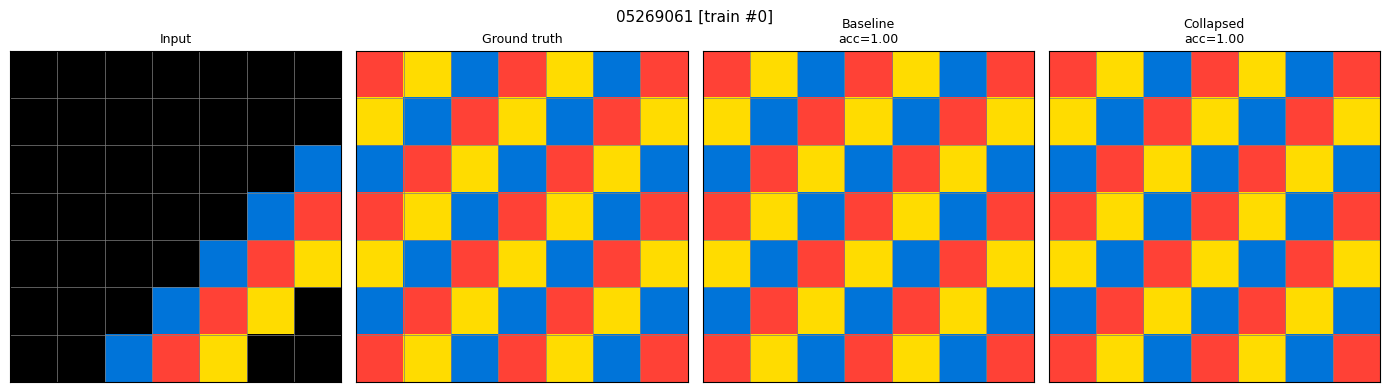

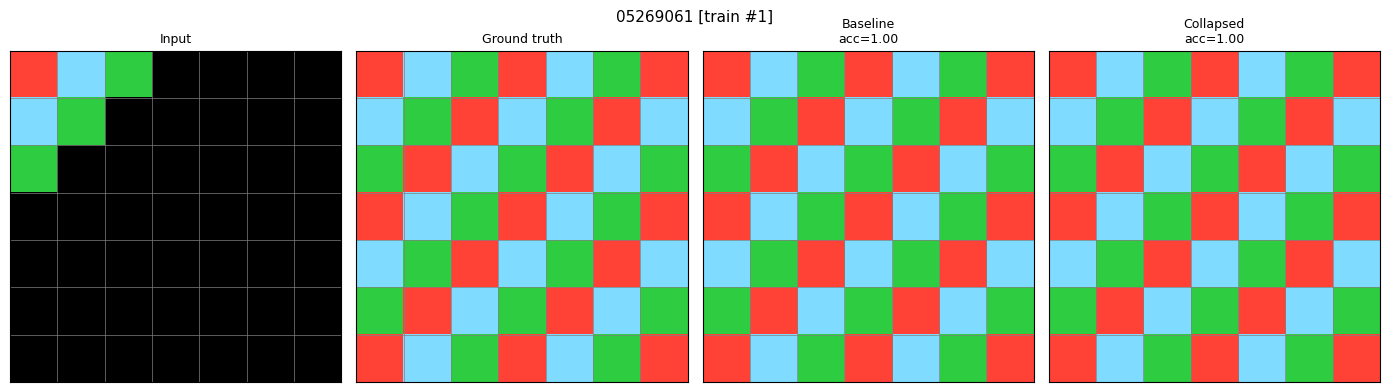

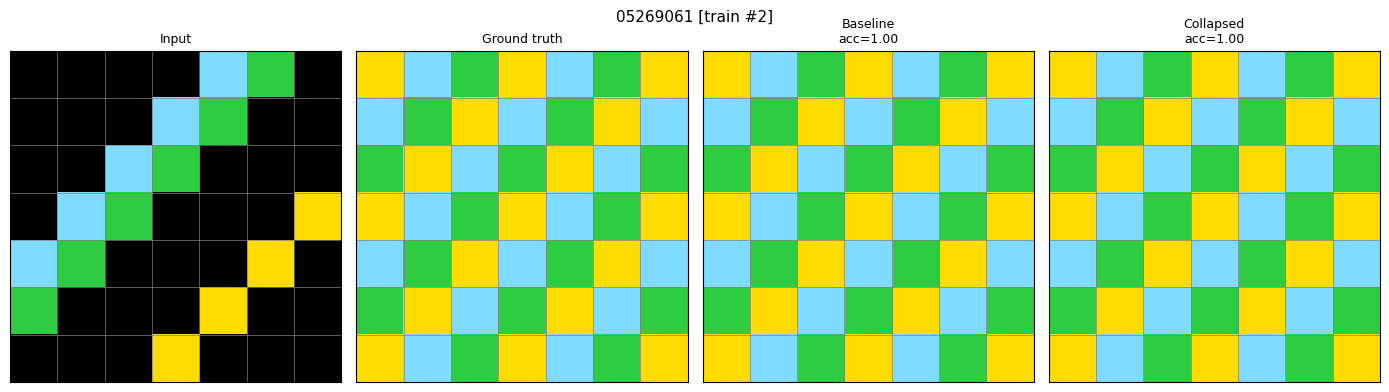

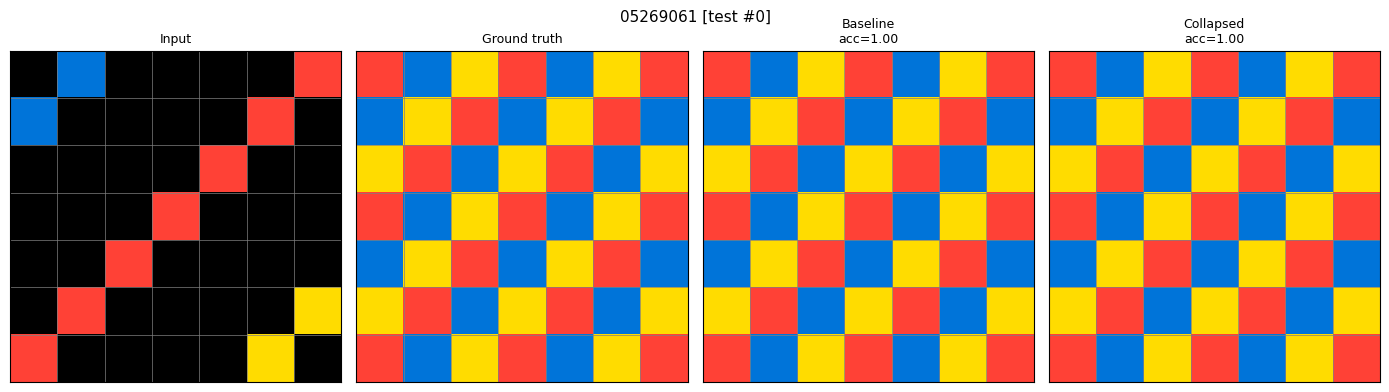

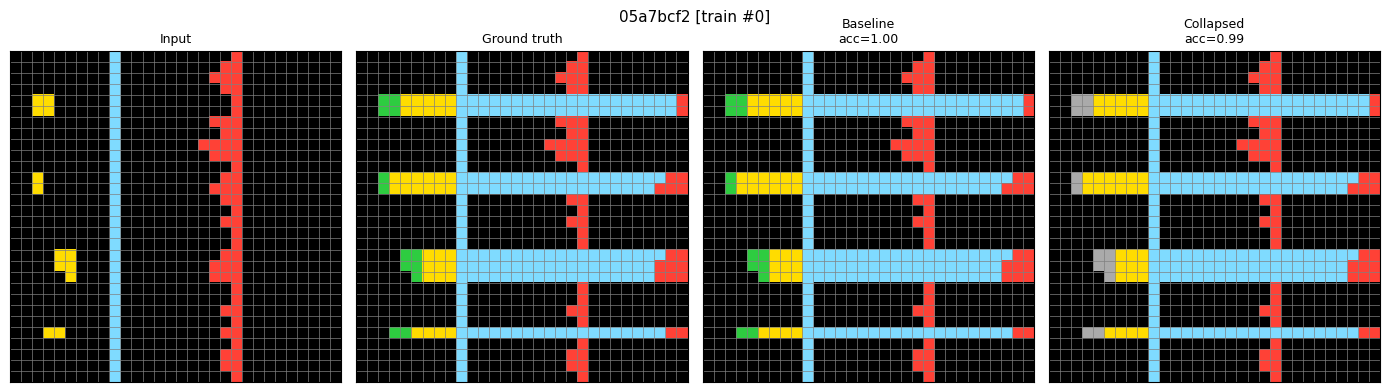

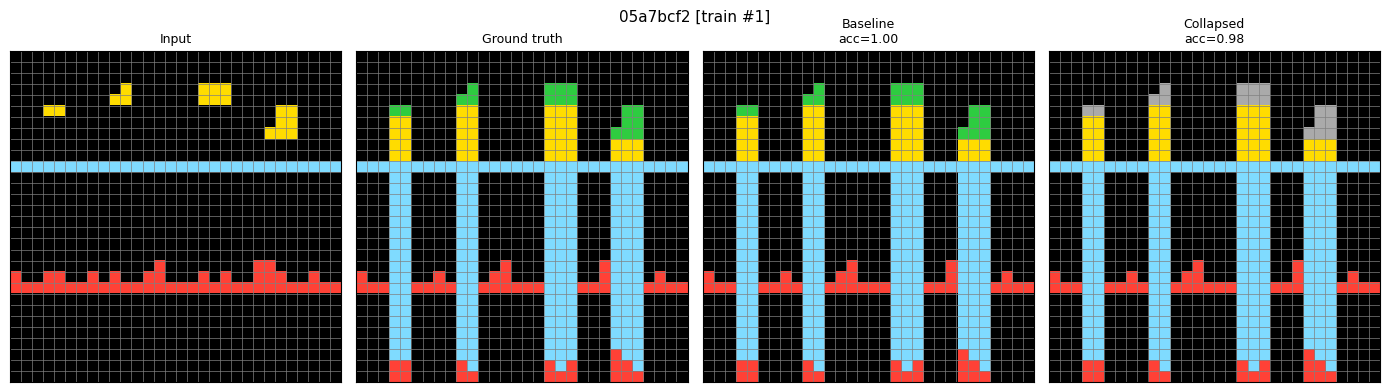

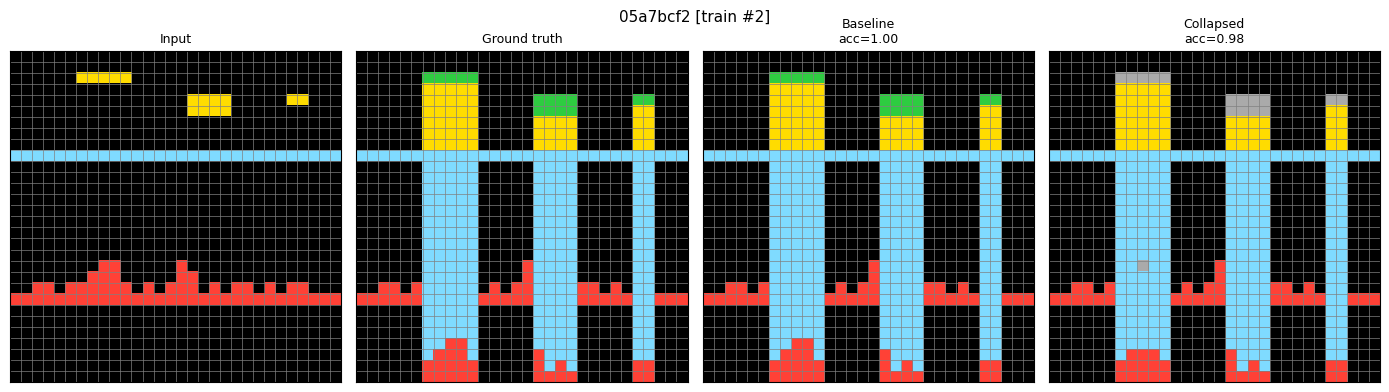

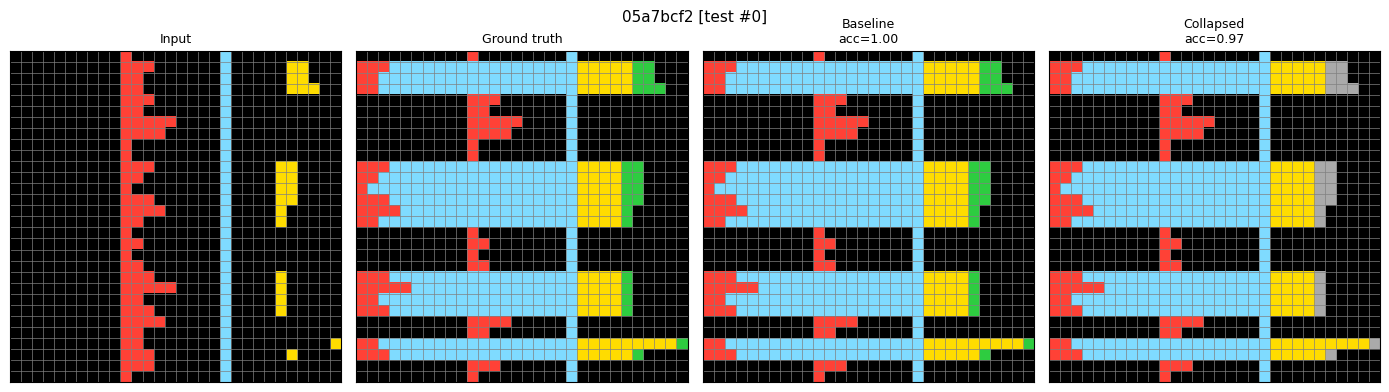

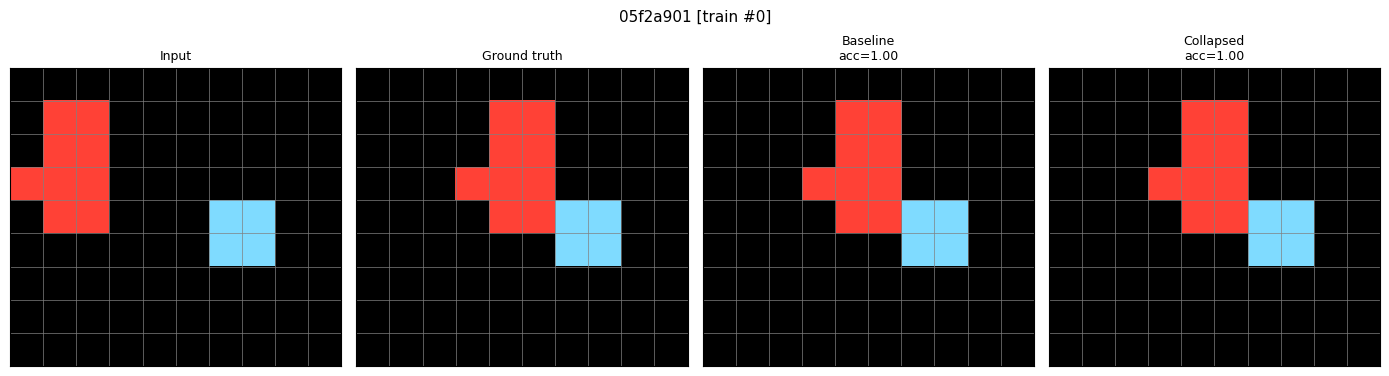

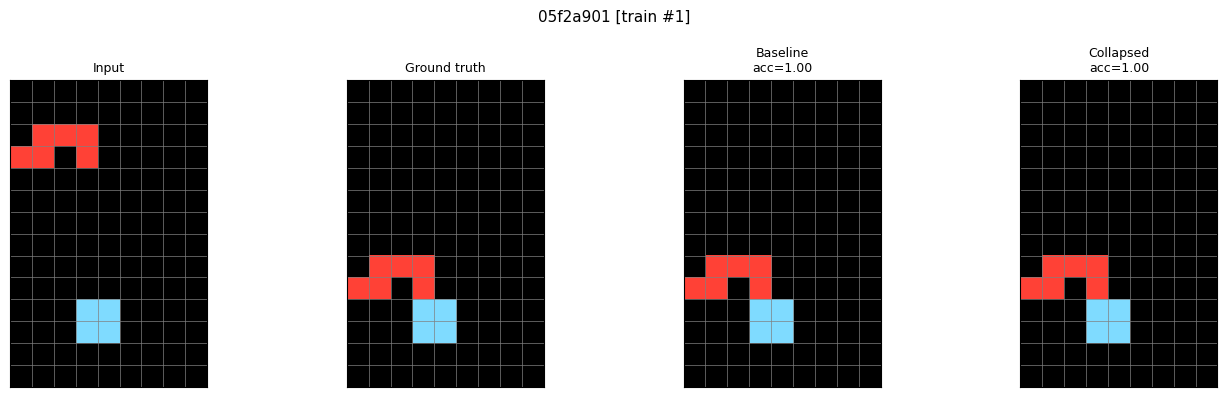

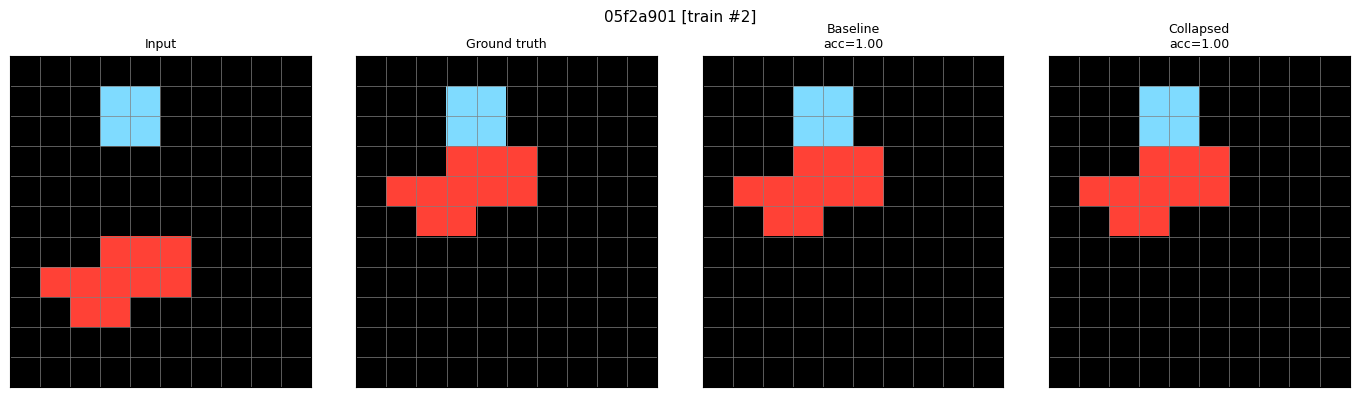

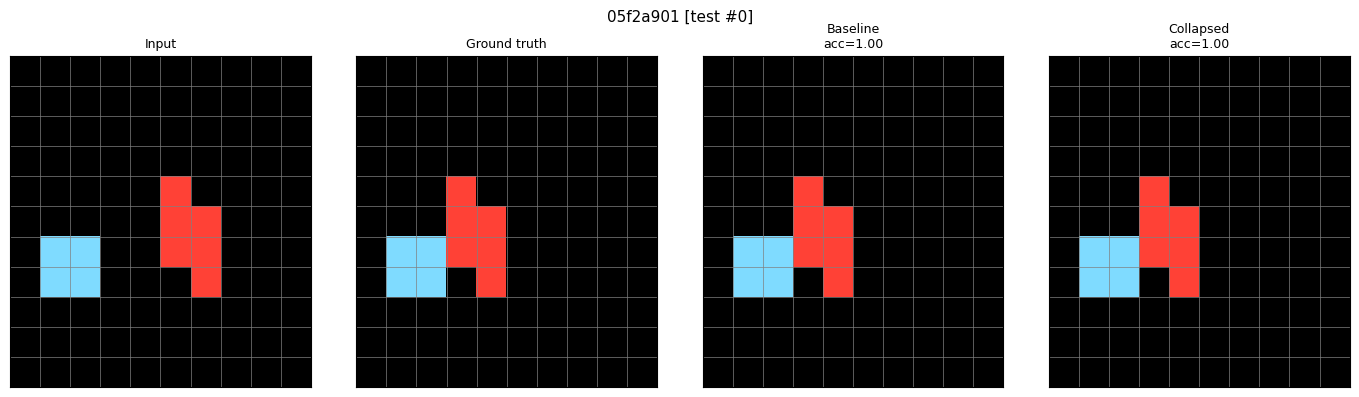

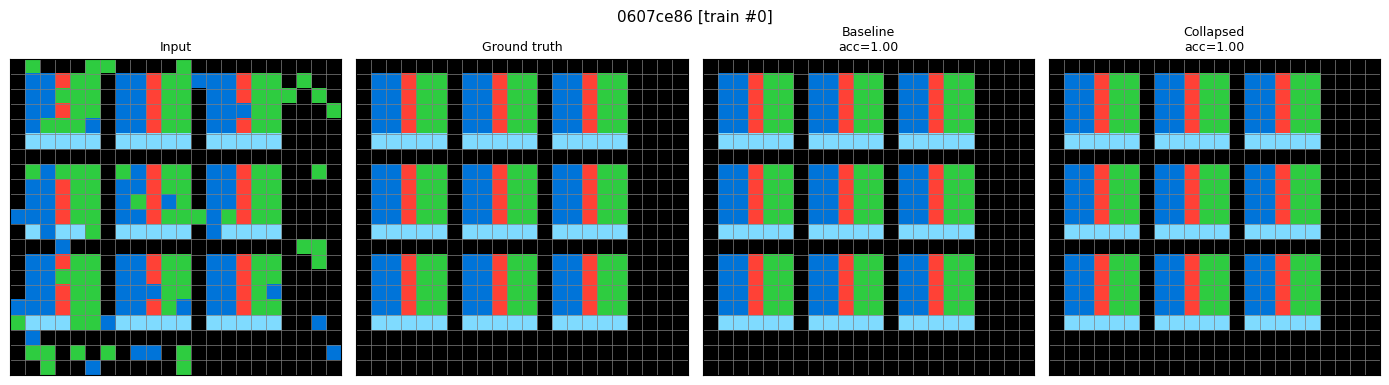

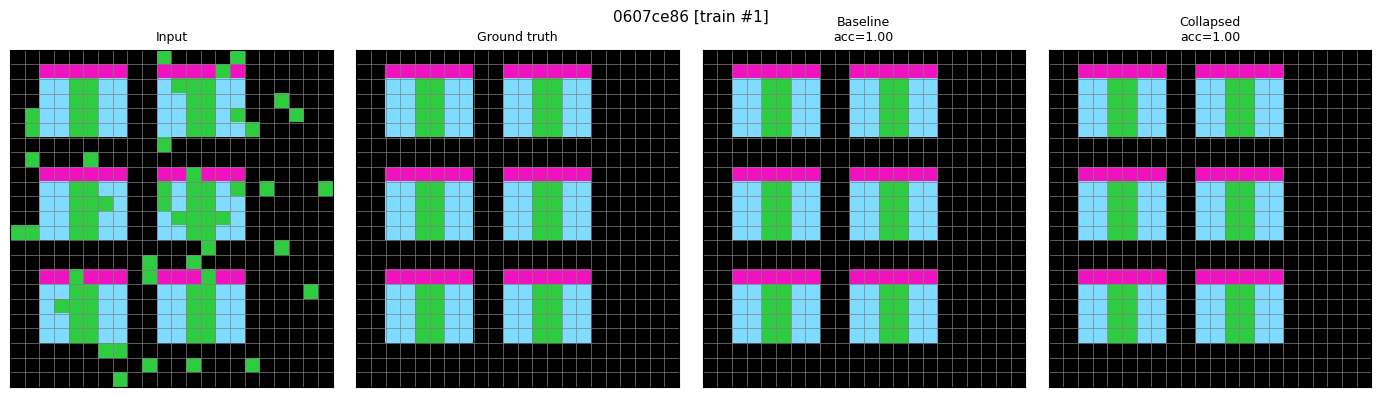

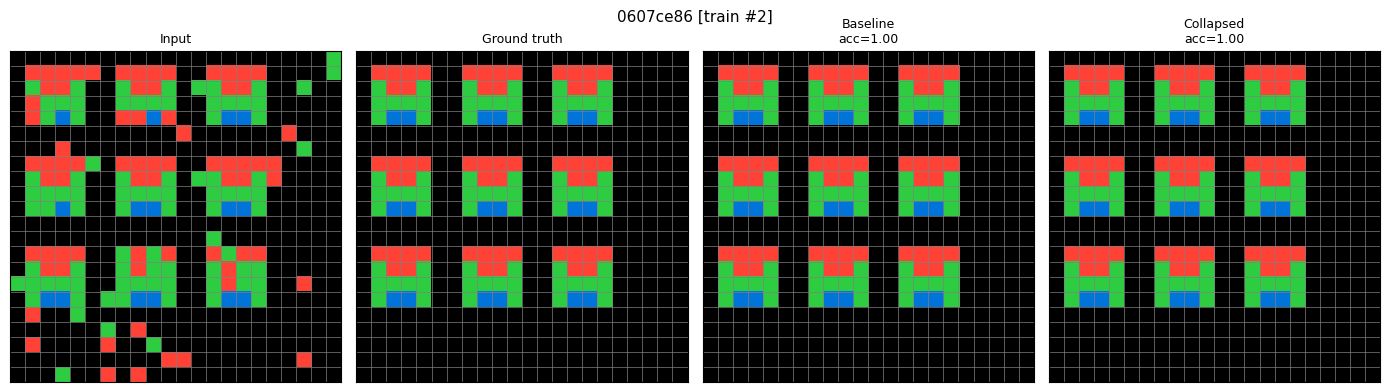

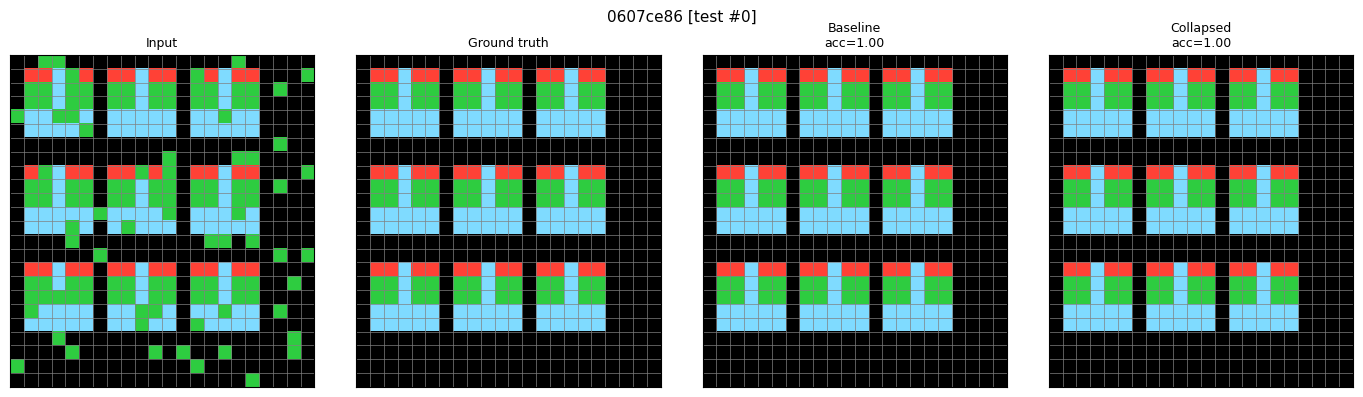

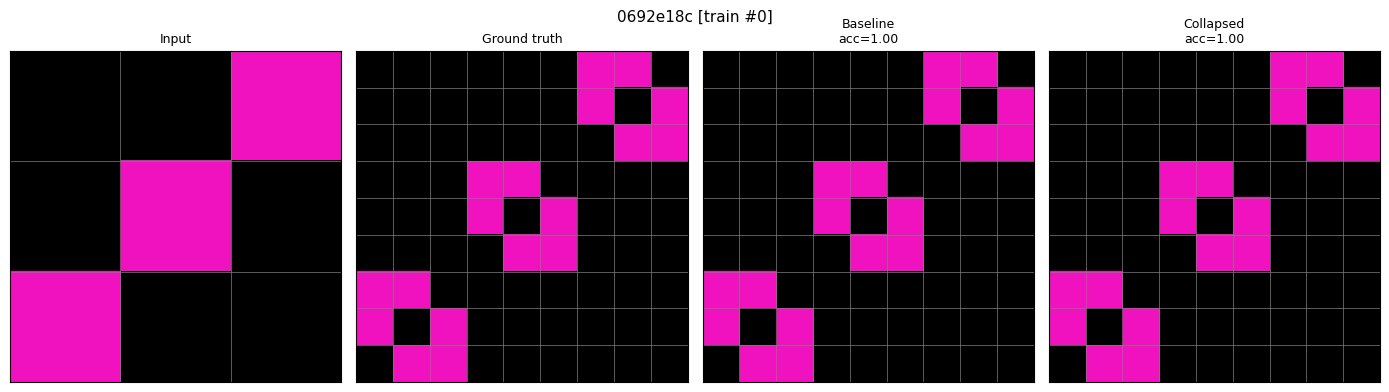

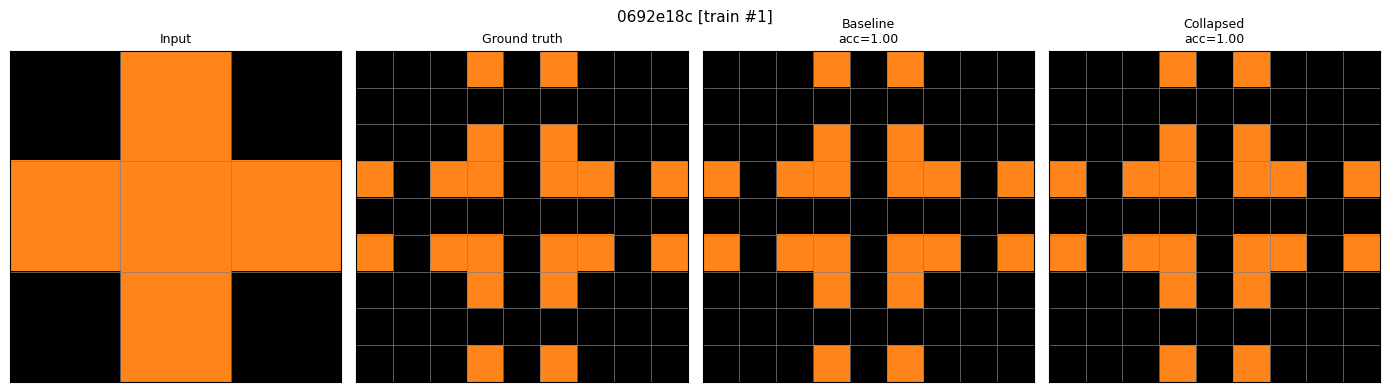

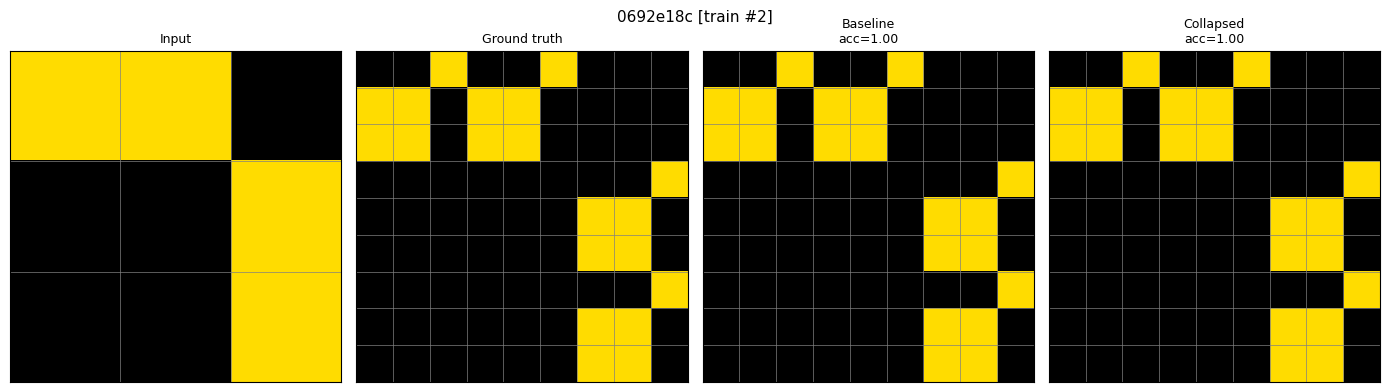

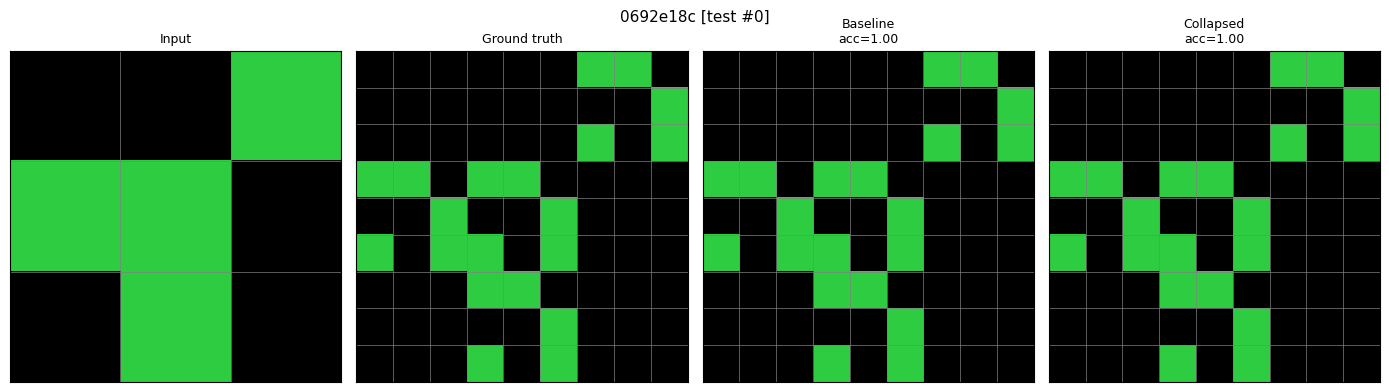

,task_id,kind,detail,baseline_cell_acc,baseline_grid_exact,collapsed_cell_acc,collapsed_grid_exact,collapsed_embedding_same_as_first
0,05269061,canonical,train[0],1.000000,1,1.000000,1,True
1,05269061,canonical,train[1],1.000000,1,1.000000,1,True
2,05269061,canonical,train[2],1.000000,1,1.000000,1,True
3,05269061,canonical,test[0],1.000000,1,1.000000,1,True
4,05269061,augmented,05269061|||t2|||0813495672,1.000000,1,1.000000,1,True
5,05269061,augmented,05269061|||t0|||0358492617,1.000000,1,1.000000,1,True
6,05269061,augmented,05269061|||t2|||0361498572,1.000000,1,1.000000,1,True
7,05269061,augmented,05269061|||t1|||0893416527,1.000000,1,1.000000,1,True
8,05269061,augmented,05269061|||t7|||0598613724,1.000000,1,1.000000,1,True
9,05a7bcf2,canonical,train[0],1.000000,1,0.985556,0,True


In [14]:

next_five_task_ids_v2 = all_task_ids_v2[10:15]
print("Testing:", next_five_task_ids_v2)

comparison_df_v2 = compare_tasks_v2(next_five_task_ids_v2, n_aug_check=5, show_plots=True)
comparison_df_v2.to_csv("/kaggle/working/comparison_results_v2.csv", index=False)
comparison_df_v2


609 tasks unique to ARC-AGI-2
Testing: ['2ccd9fef', '2de01db2', '2e65ae53', '2f0c5170', '2f767503']
2ccd9fef: averaged over 1001 rows -> overrode collapsed row 659
2de01db2: averaged over 1001 rows -> overrode collapsed row 207
2e65ae53: averaged over 1001 rows -> overrode collapsed row 489
2f0c5170: averaged over 1001 rows -> overrode collapsed row 109
2f767503: averaged over 1001 rows -> overrode collapsed row 371
                    baseline_cell_acc  collapsed_cell_acc
task_id  kind                                            
2ccd9fef augmented                1.0                 1.0
         canonical                1.0                 1.0
2de01db2 augmented                1.0                 1.0
         canonical                1.0                 1.0
2e65ae53 augmented                1.0                 1.0
         canonical                1.0                 1.0
2f0c5170 augmented                1.0                 1.0
         canonical                1.0                 1.0


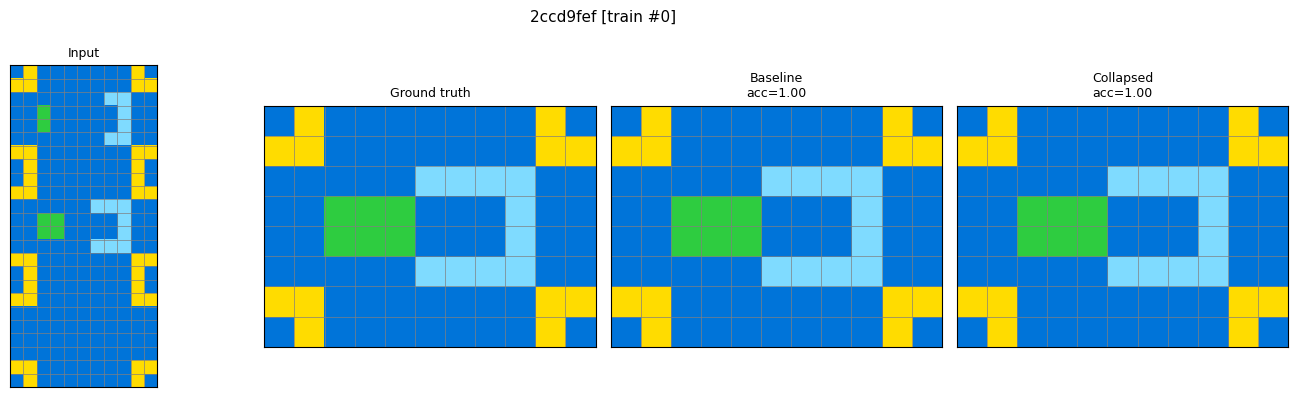

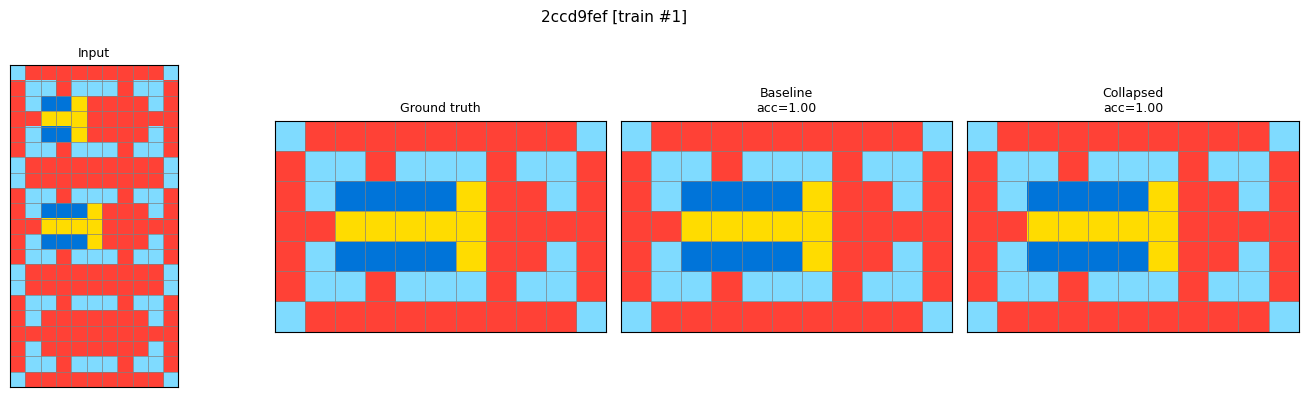

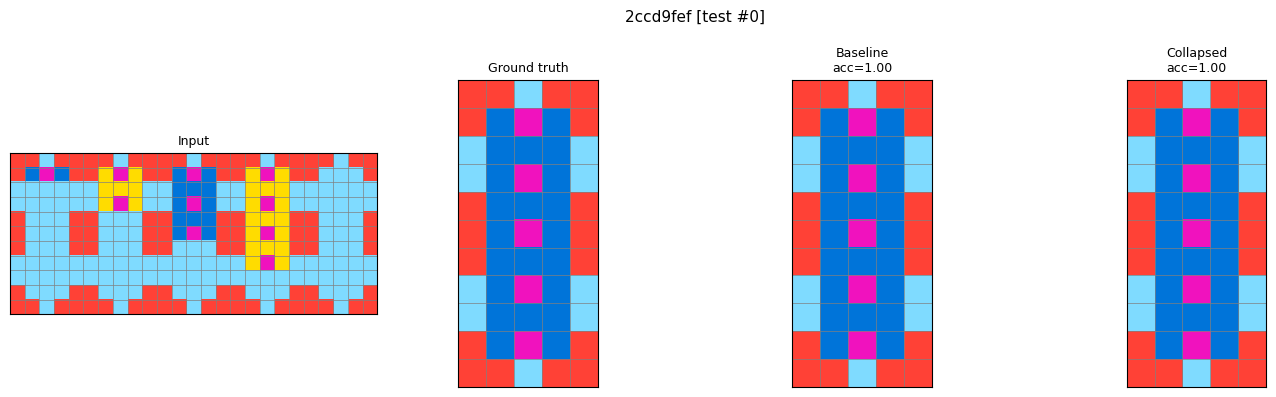

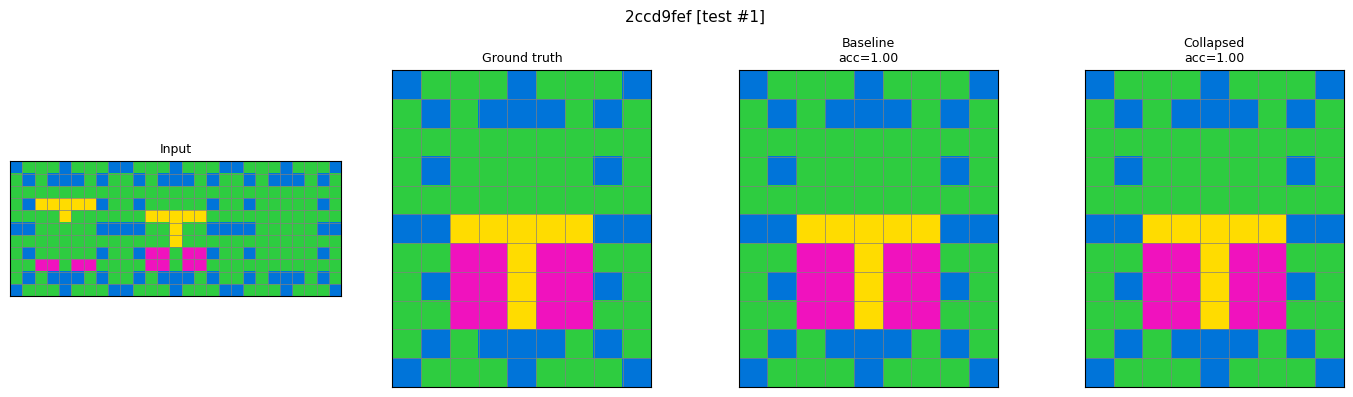

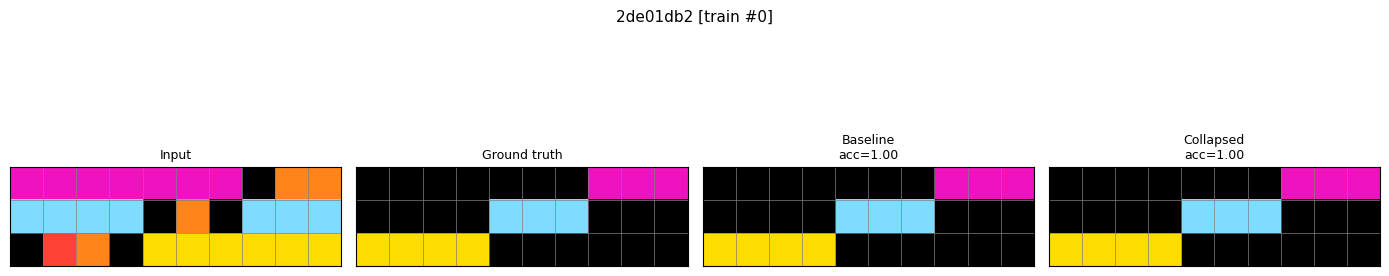

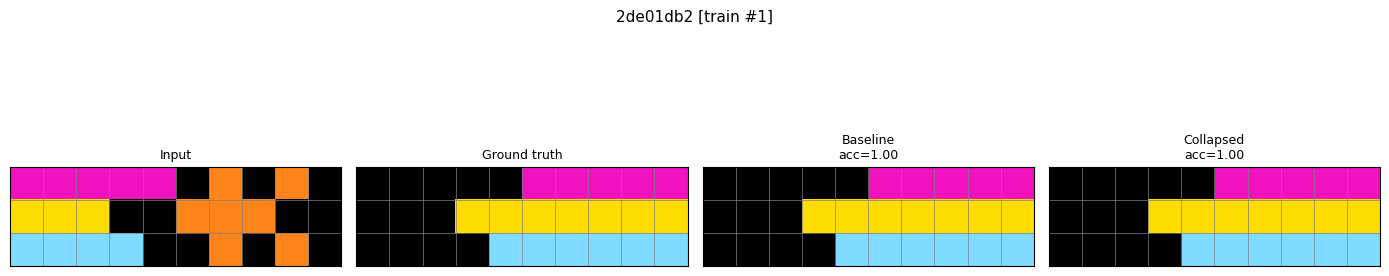

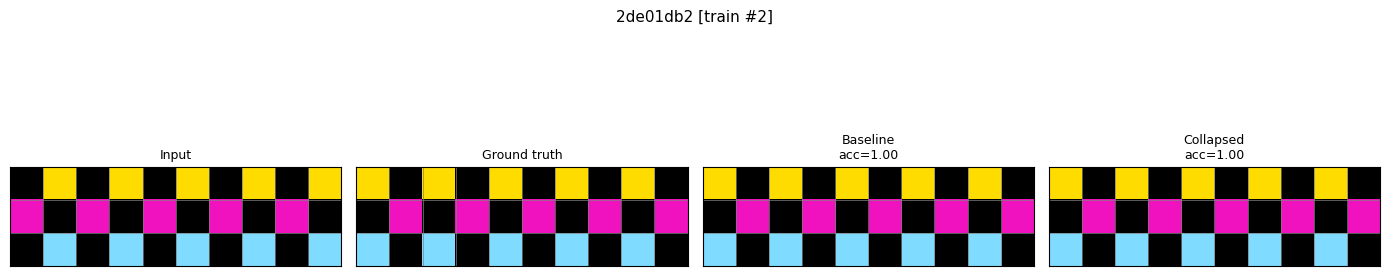

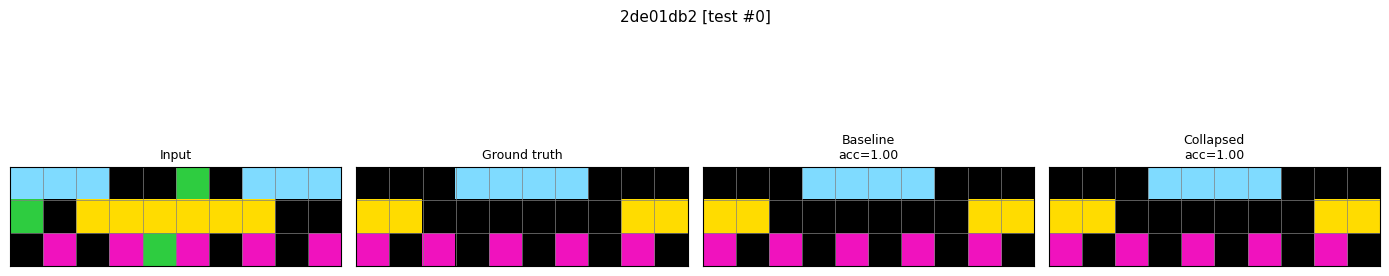

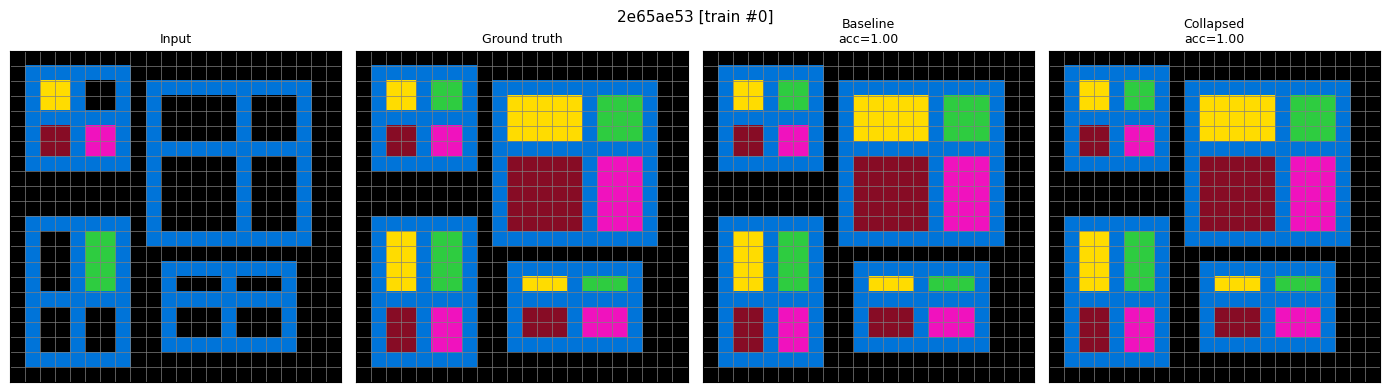

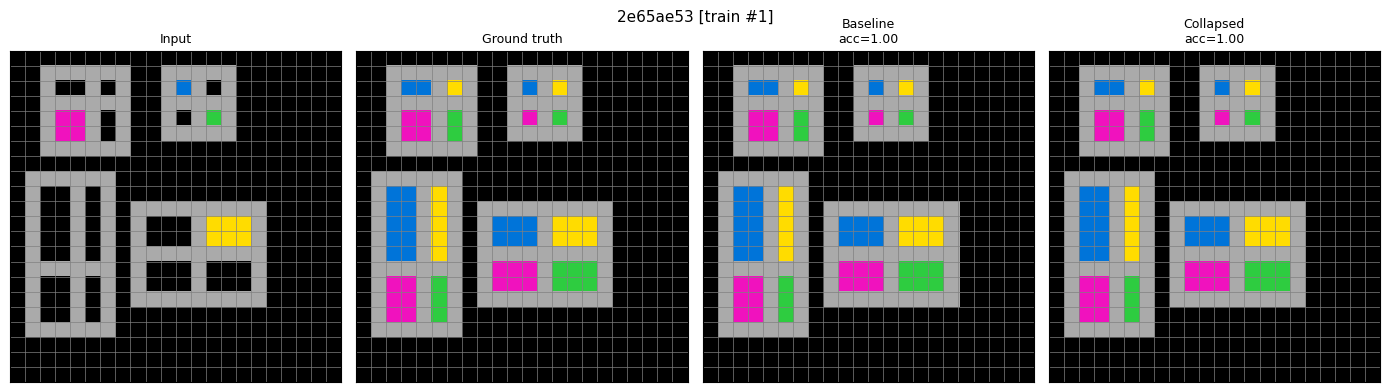

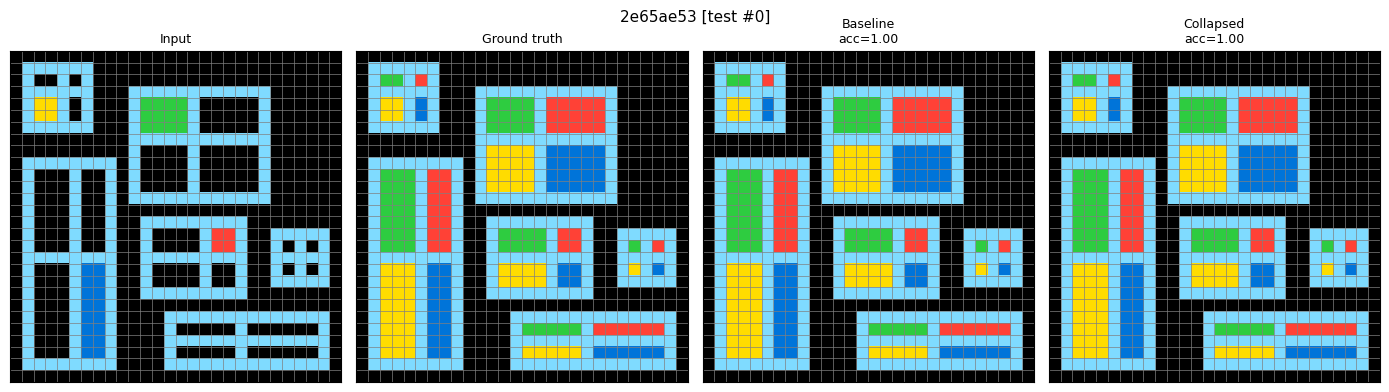

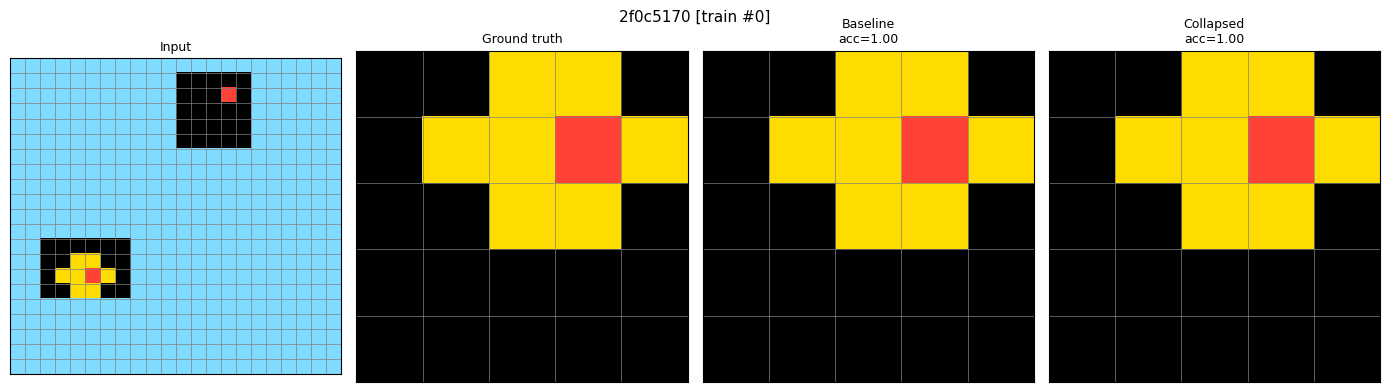

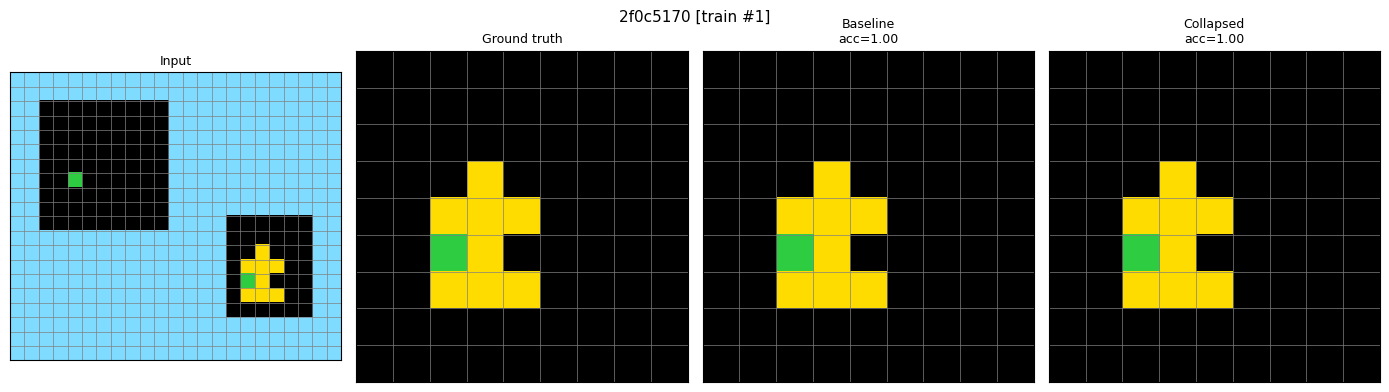

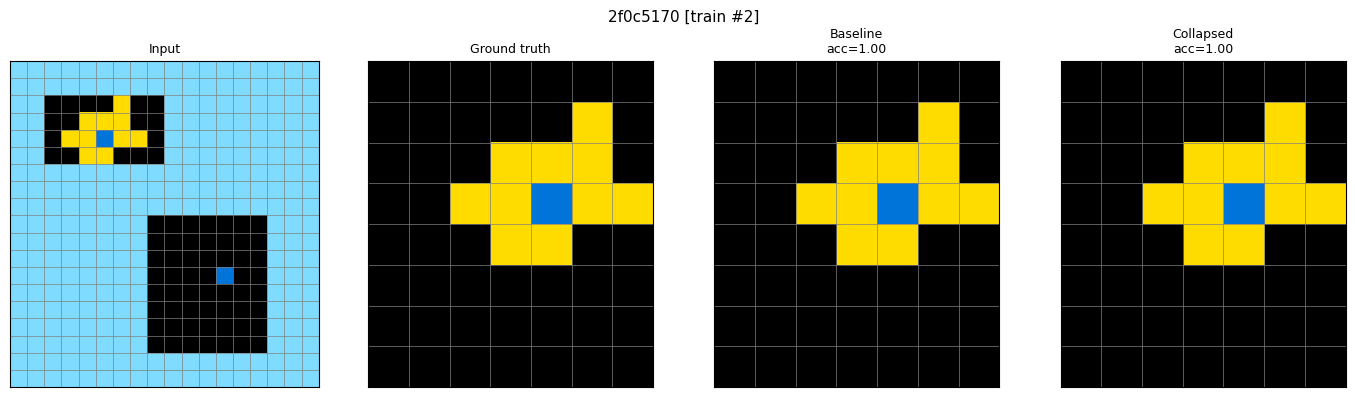

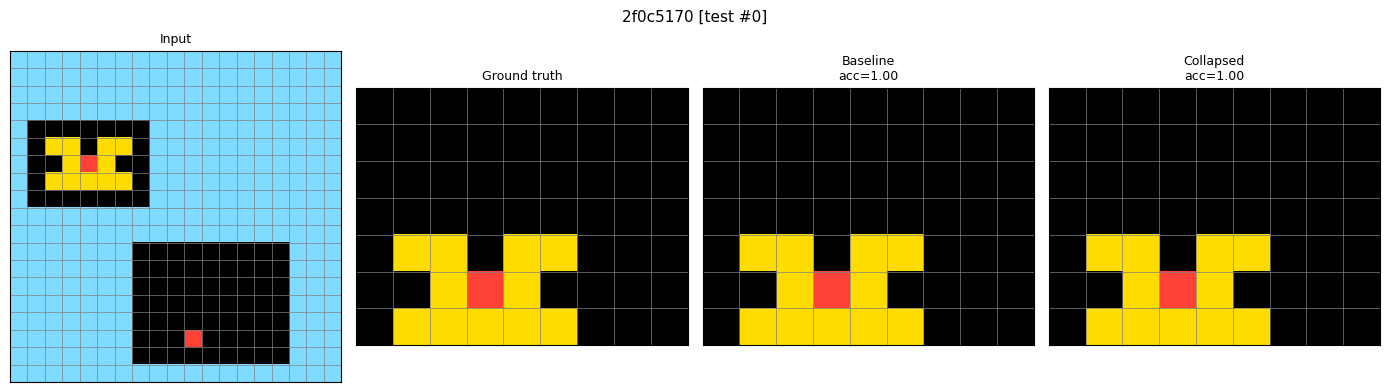

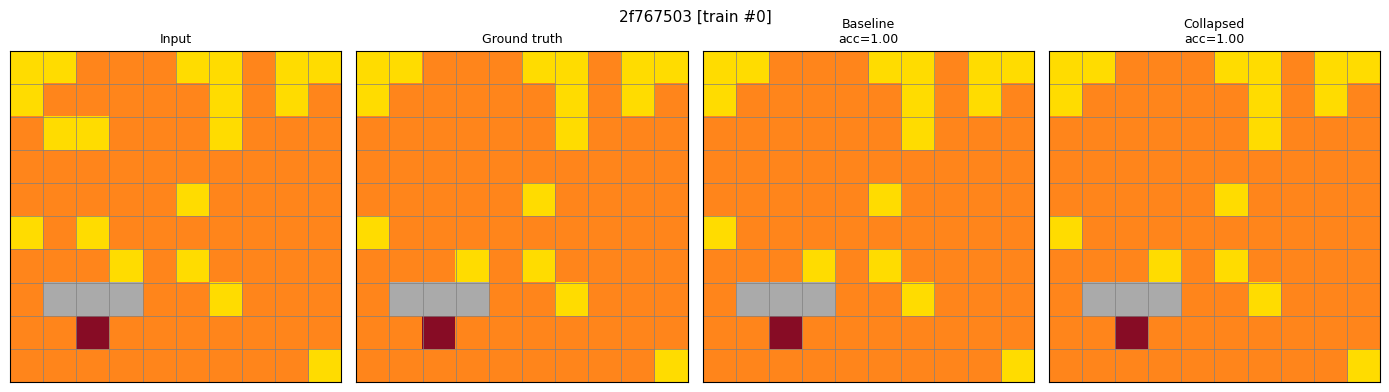

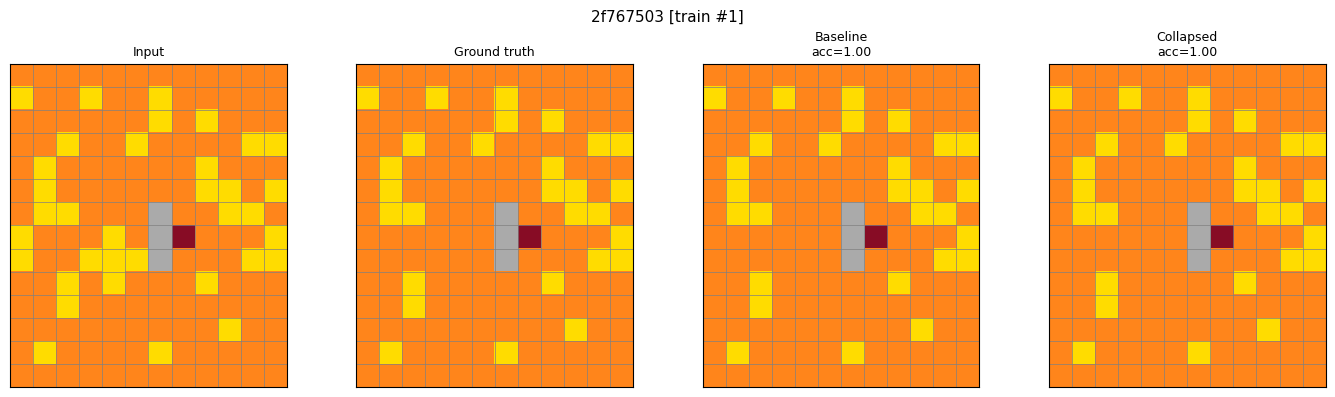

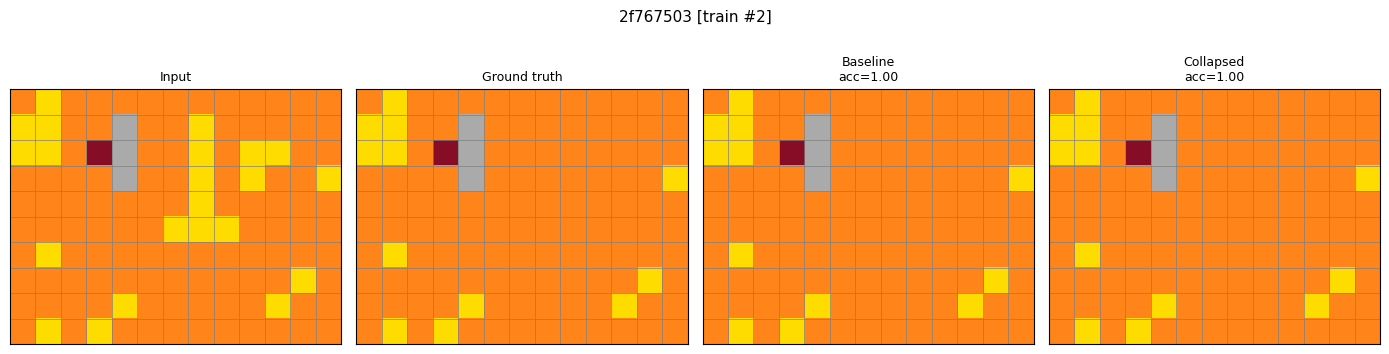

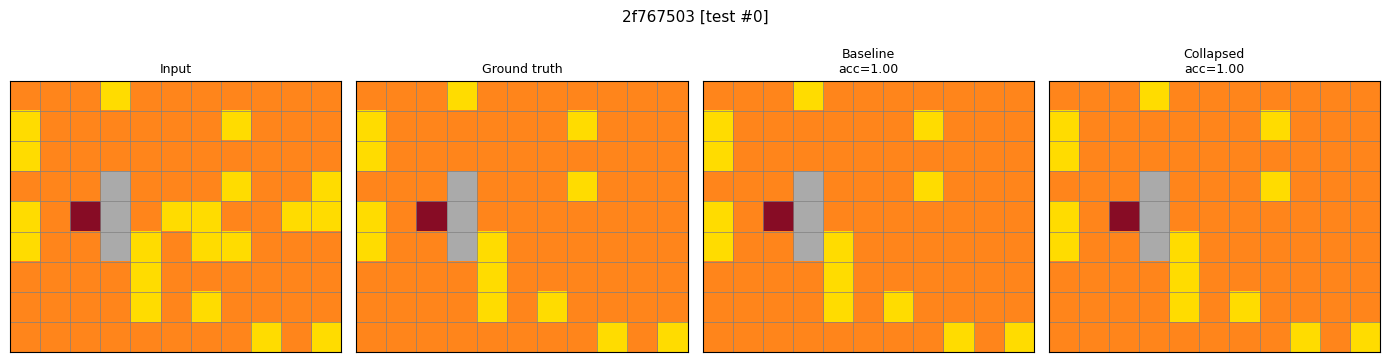

,task_id,kind,detail,baseline_cell_acc,baseline_grid_exact,collapsed_cell_acc,collapsed_grid_exact,collapsed_embedding_same_as_first
0,2ccd9fef,canonical,train[0],1.0,1,1.0,1,True
1,2ccd9fef,canonical,train[1],1.0,1,1.0,1,True
2,2ccd9fef,canonical,test[0],1.0,1,1.0,1,True
3,2ccd9fef,canonical,test[1],1.0,1,1.0,1,True
4,2ccd9fef,augmented,2ccd9fef|||t2|||0387412956,1.0,1,1.0,1,True
5,2ccd9fef,augmented,2ccd9fef|||t1|||0451372986,1.0,1,1.0,1,True
6,2ccd9fef,augmented,2ccd9fef|||t4|||0653872419,1.0,1,1.0,1,True
7,2ccd9fef,augmented,2ccd9fef|||t4|||0817294635,1.0,1,1.0,1,True
8,2ccd9fef,augmented,2ccd9fef|||t1|||0496372581,1.0,1,1.0,1,True
9,2de01db2,canonical,train[0],1.0,1,1.0,1,True


In [15]:
# Filter to ARC-AGI-2-only tasks (exclude tasks shared with ARC-AGI-1).
with open(f'{CFG["repo_dir"]}/kaggle/combined/arc-agi_training_challenges.json') as f:
    v1_task_ids = set(_json.load(f).keys())

arc2_only_task_ids = [tid for tid in all_task_ids_v2 if tid not in v1_task_ids]
print(f"{len(arc2_only_task_ids)} tasks unique to ARC-AGI-2")

next_five_task_ids_v2 = arc2_only_task_ids[100:105]
print("Testing:", next_five_task_ids_v2)

comparison_df_v2 = compare_tasks_v2(next_five_task_ids_v2, n_aug_check=5, show_plots=True)
comparison_df_v2.to_csv("/kaggle/working/comparison_results_v2_arc2only.csv", index=False)
comparison_df_v2

0ca9ddb6: averaged over 1001 rows -> overrode collapsed row 56
0ca9ddb6 has 1000 augmented rows available


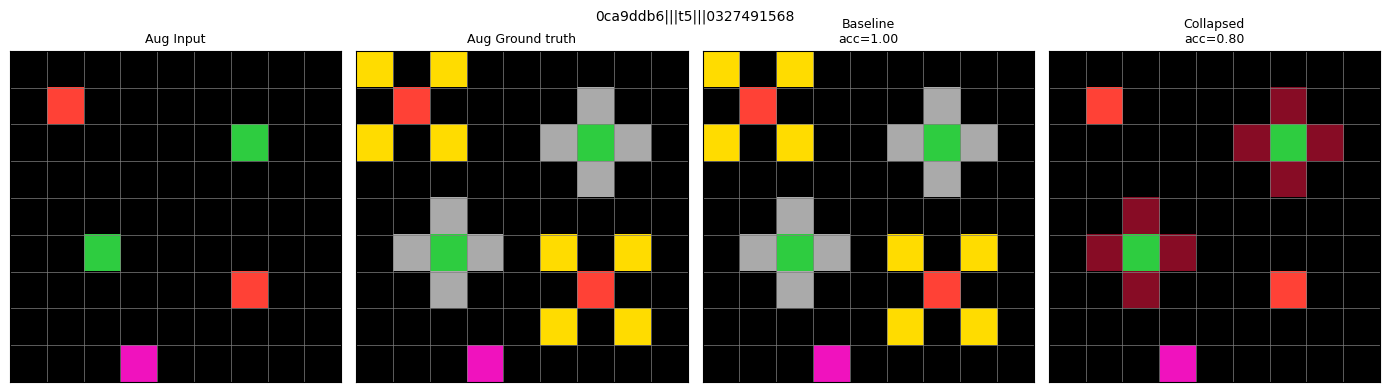

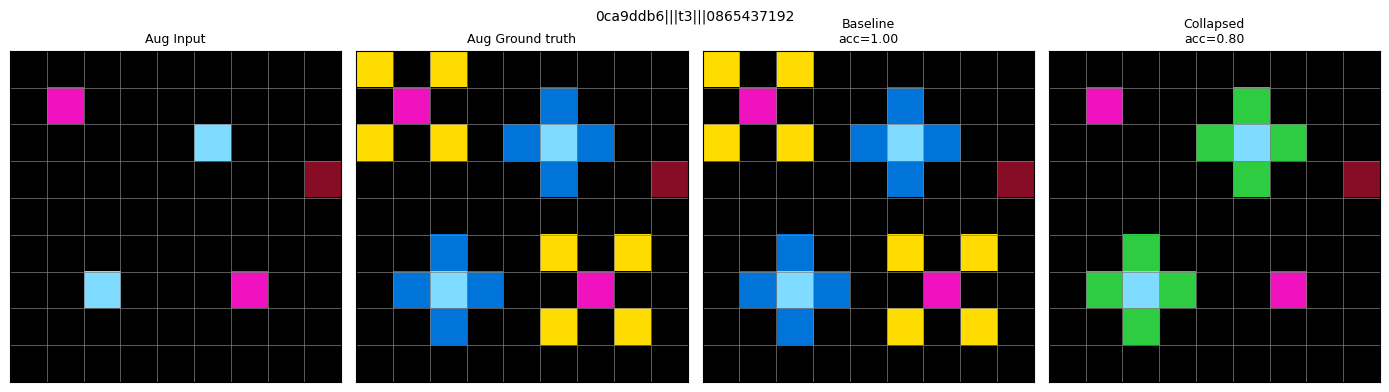

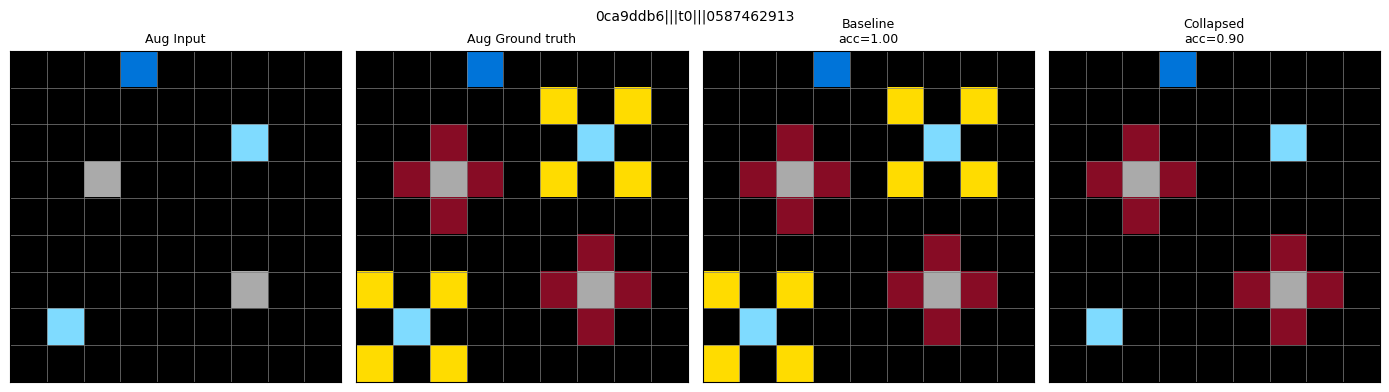

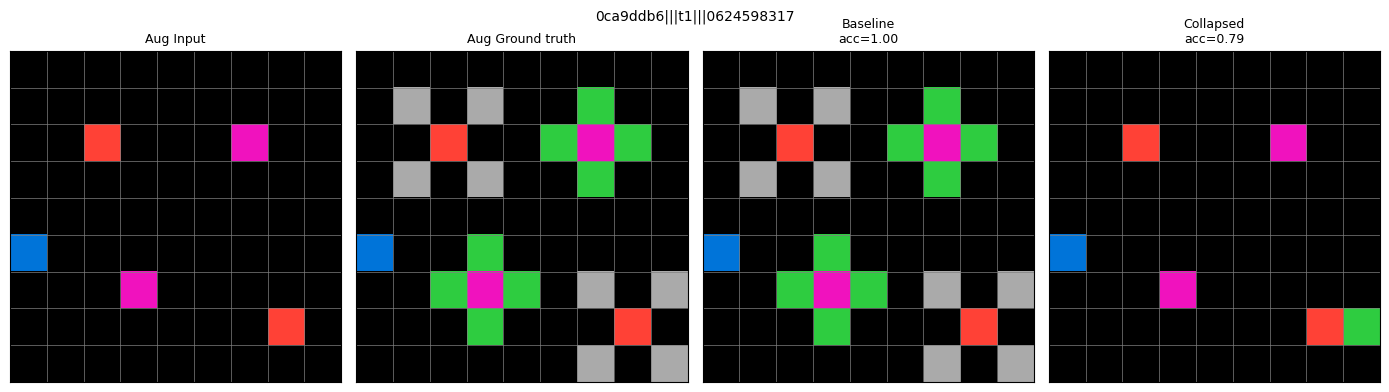

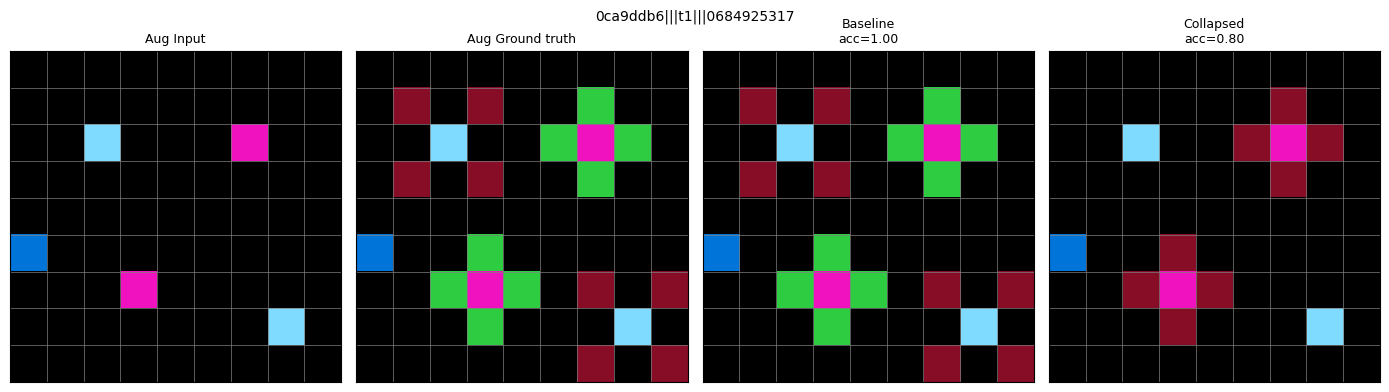

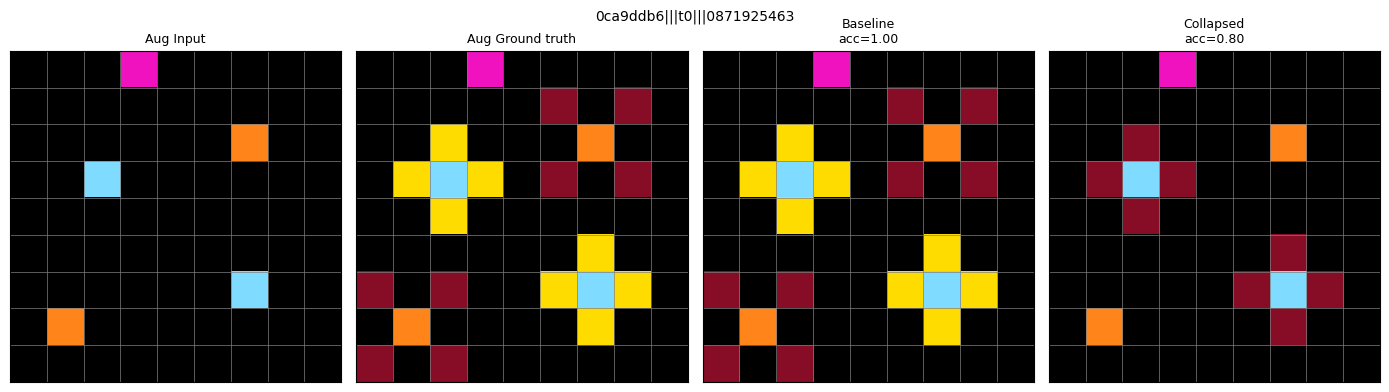

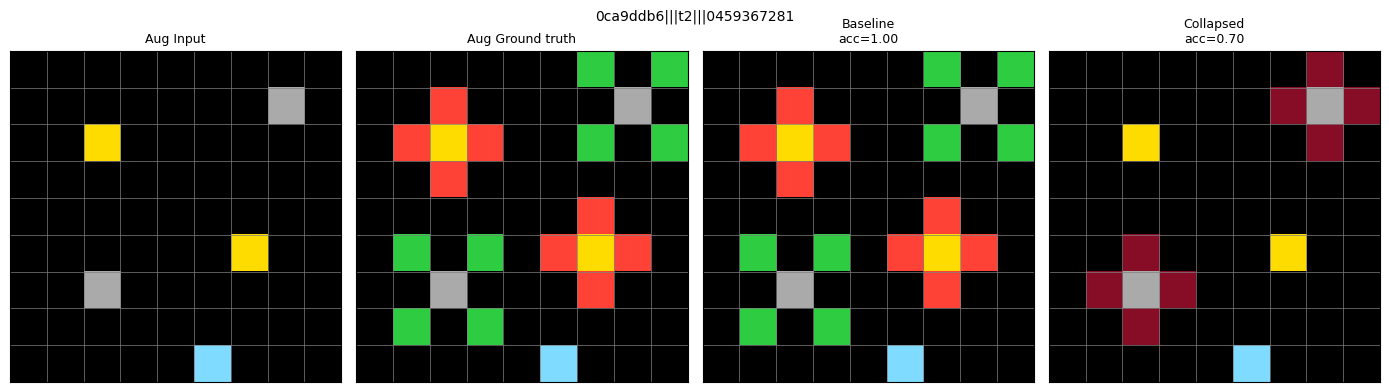

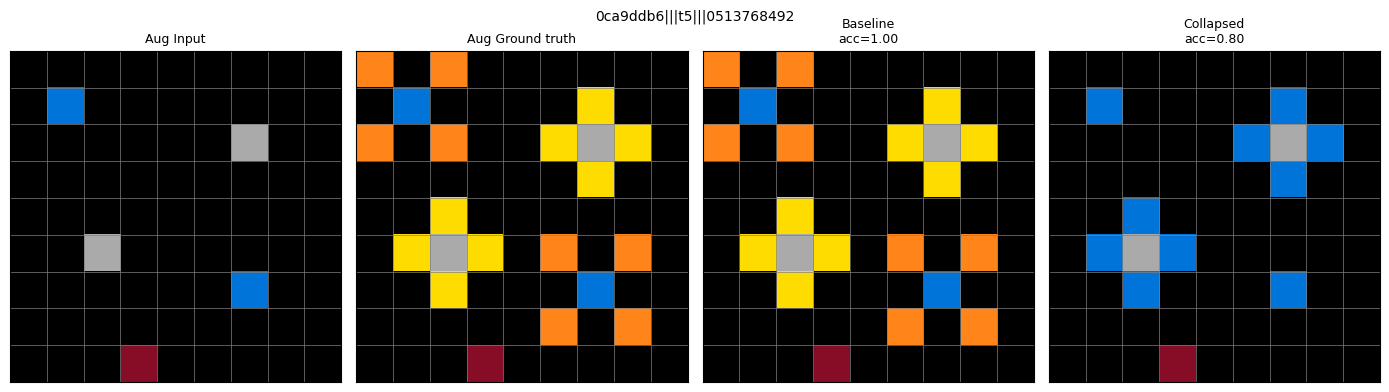

In [16]:
# Run inference on N augmented versions of a single task, with visuals.
MANUAL_TASK_ID = "0ca9ddb6"     # <-- any task_id string, must exist in task_to_id_v2_baseline
N_AUGS_TO_VISUALIZE = 8         # <-- how many of the ~1000 augmented rows to actually run+plot
BASE_EXAMPLE = ("train", 0)     # <-- which canonical demo pair to transform; ("test", 0) also valid
AUG_SAMPLE_SEED = 0             # <-- change this to see a different random sample of augmentations

assert MANUAL_TASK_ID in task_to_id_v2_baseline, \
    f"'{MANUAL_TASK_ID}' not found in task_to_id_v2_baseline -- check spelling / that it's in all_task_ids_v2"

ensure_collapsed_embedding_v2(MANUAL_TASK_ID)
collapsed_id = task_to_id_v2_collapsed[MANUAL_TASK_ID]

# All real augmented rows this task actually has in the built dataset (up to ~1000)
aug_rows = [(i, name) for i, name in enumerate(v2_baseline_ids)
            if name.startswith(MANUAL_TASK_ID + PuzzleIdSeparator)]
print(f"{MANUAL_TASK_ID} has {len(aug_rows)} augmented rows available")

random.seed(AUG_SAMPLE_SEED)
sampled = random.sample(aug_rows, min(N_AUGS_TO_VISUALIZE, len(aug_rows)))

split_name, ex_idx = BASE_EXAMPLE

if MANUAL_TASK_ID in tasks_v2:
    task_source = tasks_v2
elif MANUAL_TASK_ID in tasks_v2_eval:
    task_source = tasks_v2_eval
else:
    raise KeyError(f"'{MANUAL_TASK_ID}' not found in tasks_v2 or tasks_v2_eval")

base_ex = task_source[MANUAL_TASK_ID][split_name][ex_idx]


for row_id, row_name in sampled:
    aug_inp = apply_named_transform(base_ex["input"], row_name).tolist()
    aug_out = apply_named_transform(base_ex["output"], row_name).tolist()

    # Baseline: this row's own distinct per-augmentation embedding.
    pred_baseline = run_single(model_v2_baseline, aug_inp, row_id, meta_v2_baseline)
    # Collapsed: the same single averaged embedding, reused for every augmentation.
    pred_collapsed = run_single(model_v2_collapsed, aug_inp, collapsed_id, meta_v2_collapsed)

    b_acc = cell_accuracy(pred_baseline, aug_out)
    c_acc = cell_accuracy(pred_collapsed, aug_out)

    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    show_grid(axes[0], aug_inp, "Aug Input")
    show_grid(axes[1], aug_out, "Aug Ground truth")
    show_grid(axes[2], pred_baseline, f"Baseline\nacc={b_acc:.2f}")
    show_grid(axes[3], pred_collapsed, f"Collapsed\nacc={c_acc:.2f}")
    fig.suptitle(f"{row_name}", fontsize=10)
    plt.tight_layout()
    plt.show()

## Visualizing random puzzles

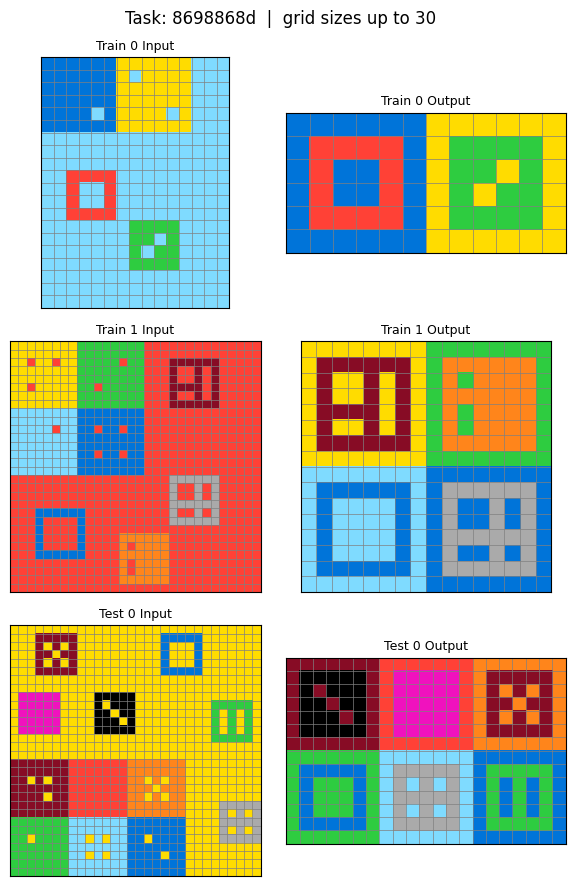

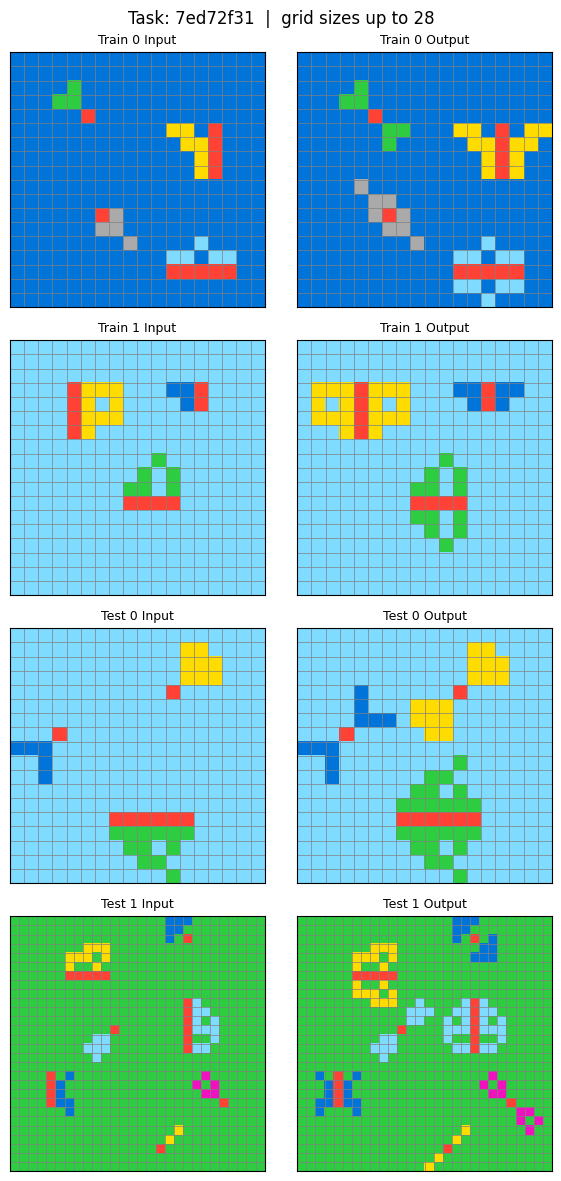

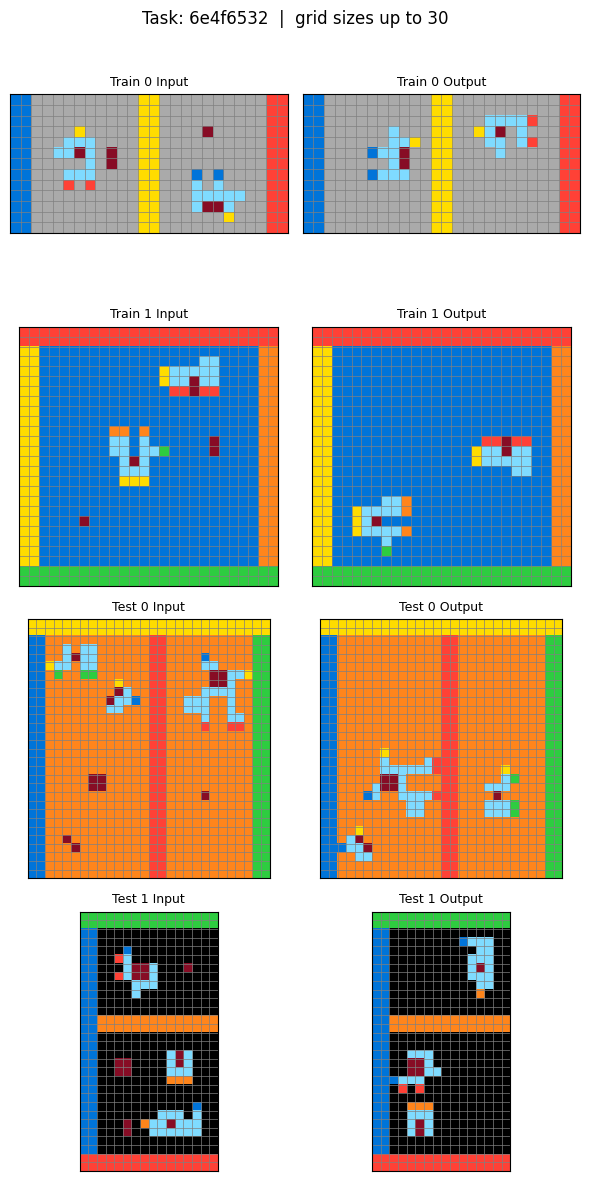

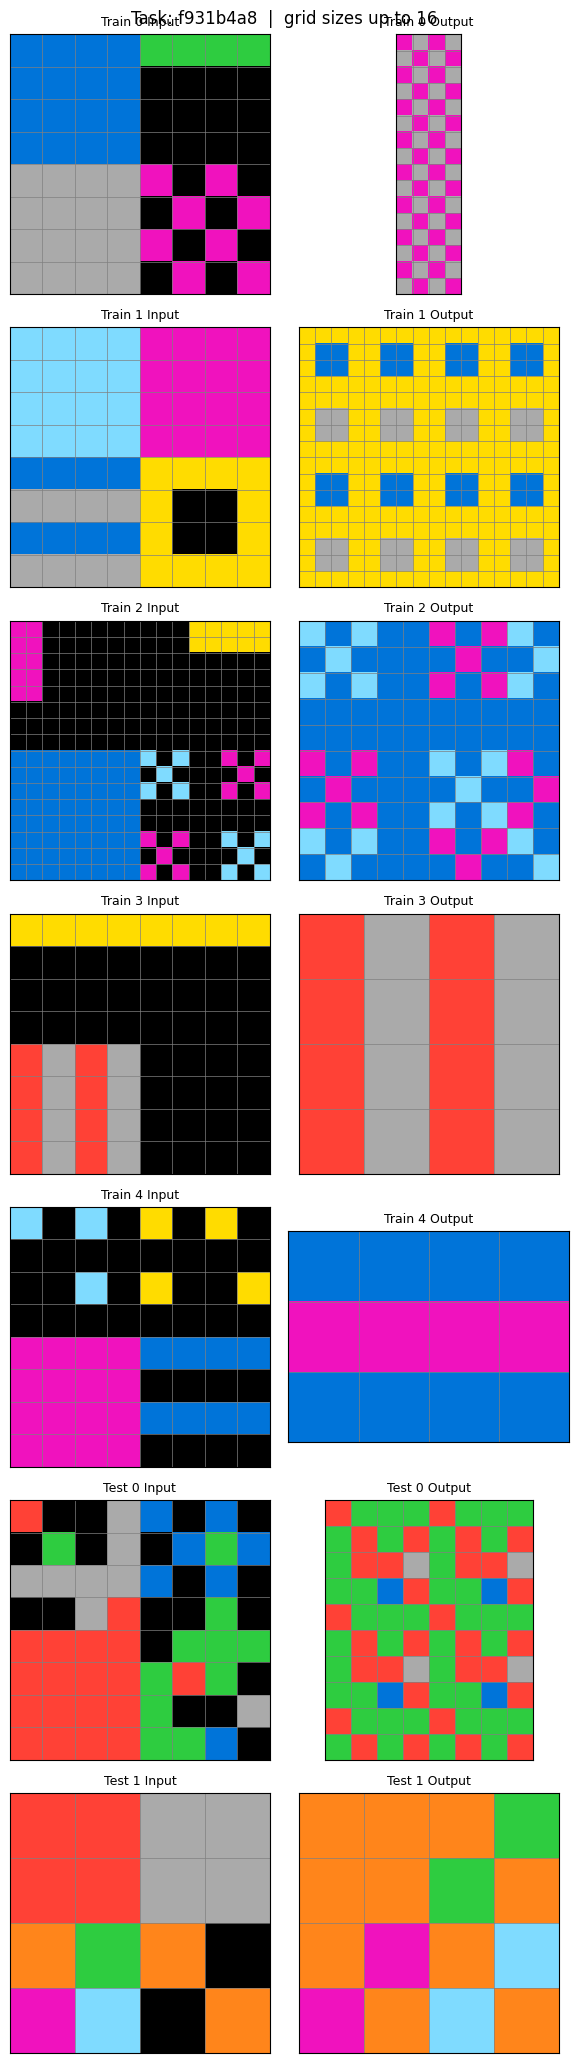

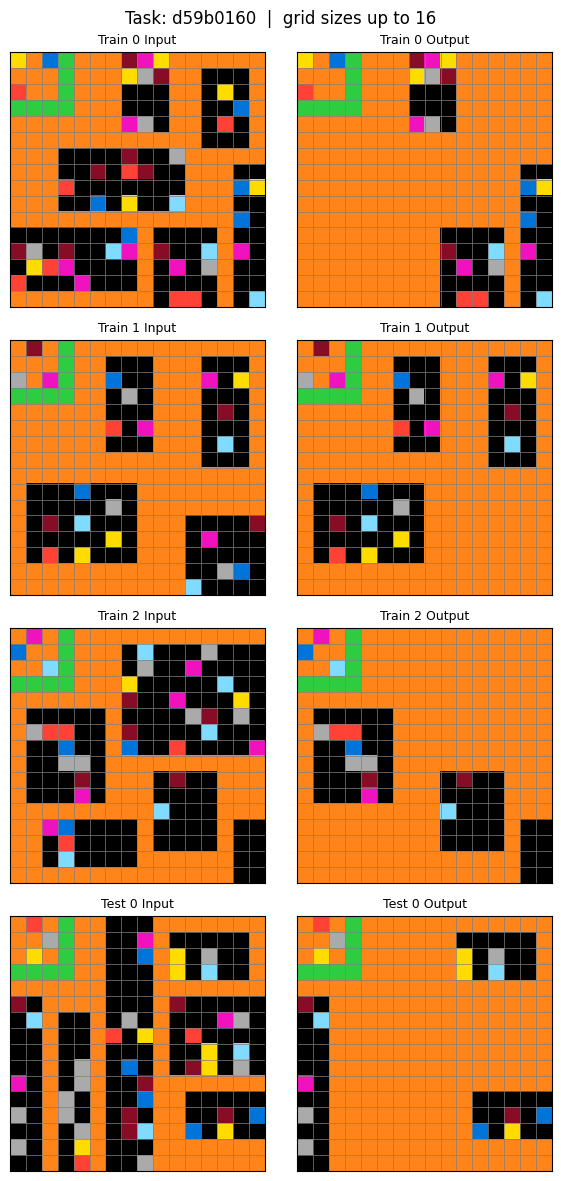

['8698868d', '7ed72f31', '6e4f6532', 'f931b4a8', 'd59b0160']

In [17]:
# Pure visualization: browse random puzzles, no model inference.
import random

def visualize_puzzle(task_id, tasks_dict, max_train=6):
    task = tasks_dict[task_id]
    train_pairs = task["train"][:max_train]
    test_pairs = task["test"]

    n_rows = len(train_pairs) + len(test_pairs)
    fig, axes = plt.subplots(n_rows, 2, figsize=(6, 3 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, 2)

    for i, ex in enumerate(train_pairs):
        show_grid(axes[i, 0], ex["input"], f"Train {i} Input")
        show_grid(axes[i, 1], ex["output"], f"Train {i} Output")

    for j, ex in enumerate(test_pairs):
        row = len(train_pairs) + j
        show_grid(axes[row, 0], ex["input"], f"Test {j} Input")
        if "output" in ex:
            show_grid(axes[row, 1], ex["output"], f"Test {j} Output")
        else:
            axes[row, 1].axis("off")
            axes[row, 1].set_title("Test Output (hidden)")

    fig.suptitle(f"Task: {task_id}  |  grid sizes up to "
                 f"{max(max(len(g['input']), len(g['input'][0])) for g in task['train'] + task['test'])}",
                 fontsize=12)
    plt.tight_layout()
    plt.show()


def visualize_random_puzzles(tasks_dict, n=5, seed=None, min_grid_size=0):
    """min_grid_size filters for larger grids, e.g. min_grid_size=15 to skip
    tiny, simple tasks."""
    if seed is not None:
        random.seed(seed)
    candidates = list(tasks_dict.keys())
    if min_grid_size > 0:
        candidates = [
            tid for tid in candidates
            if max(max(len(g["input"]), len(g["input"][0]))
                   for g in tasks_dict[tid]["train"] + tasks_dict[tid]["test"]) >= min_grid_size
        ]
        print(f"{len(candidates)}/{len(tasks_dict)} tasks have a grid >= {min_grid_size}x{min_grid_size}")

    sampled = random.sample(candidates, min(n, len(candidates)))
    for task_id in sampled:
        visualize_puzzle(task_id, tasks_dict)
    return sampled


# Examples:
# visualize_random_puzzles(tasks_v2, n=5)                              # random from training2
visualize_random_puzzles(tasks_v2_eval, n=5)                         # random from evaluation2 (the harder, novel ones)
# visualize_random_puzzles(tasks_v2_eval, n=5, min_grid_size=20)       # bias toward big/complex-looking grids

## 10. Save and upload the collapsed dataset and model to a Kaggle Dataset

So future sessions can attach this instead of rebuilding everything above.

**Before running this**: fill in `KAGGLE_DATASET_OWNER` with your Kaggle username, and make sure a Kaggle API token is available (Notebook settings → Add-ons → "Kaggle credentials", or `KAGGLE_USERNAME`/`KAGGLE_KEY` env vars).

Only task rows already overridden via `ensure_collapsed_embedding_v2()` (i.e. every task passed to `compare_tasks_v2()` so far) are baked into the saved model. Run `compare_tasks_v2()` on any additional tasks you want included before this cell.

In [18]:

import shutil

KAGGLE_DATASET_OWNER = "rishisujitham25b128"   # fill in your Kaggle username
KAGGLE_DATASET_SLUG  = "trm-collapsed-puzzle-id-v2"

export_dir_v2 = Path("/kaggle/working/trm_collapsed_export_v2")
export_dir_v2.mkdir(parents=True, exist_ok=True)

# Collapsed dataset: identifiers.json, per-split dataset.json, puzzle_identifiers.npy.
shutil.copytree(v2_collapsed_data, export_dir_v2 / "dataset", dirs_exist_ok=True)

# Collapsed model weights, with every embedding row overridden so far.
torch.save(model_v2_collapsed.state_dict(), export_dir_v2 / "collapsed_model_arc_2.pt")
with open(export_dir_v2 / "overridden_task_ids.json", "w") as f:
    _json.dump(list(task_averaged_embeddings_v2.keys()), f)

# Kaggle dataset metadata, required by the CLI.
dataset_metadata = {
    "title": "TRM collapsed puzzle-id dataset + model (ARC-AGI-2)",
    "id": f"{KAGGLE_DATASET_OWNER}/{KAGGLE_DATASET_SLUG}",
    "licenses": [{"name": "CC0-1.0"}],
}
with open(export_dir_v2 / "dataset-metadata.json", "w") as f:
    _json.dump(dataset_metadata, f)

print("Export staged at", export_dir_v2)
print("Contents:", os.listdir(export_dir_v2))


Export staged at /kaggle/working/trm_collapsed_export_v2
Contents: ['overridden_task_ids.json', 'dataset-metadata.json', 'dataset', 'collapsed_model_arc_2.pt']


In [19]:

# First run against a given slug uses `kaggle datasets create`; subsequent runs
# use `kaggle datasets version` (create errors if the dataset already exists).
# This cell tries create first and falls back to version automatically.
result = subprocess.run(
    ["kaggle", "datasets", "create", "-p", str(export_dir_v2), "-r", "zip"],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("create failed (likely already exists) -- trying version update instead")
    print(result.stderr)
    result2 = subprocess.run(
        ["kaggle", "datasets", "version", "-p", str(export_dir_v2), "-r", "zip",
         "-m", "Updated ARC-AGI-2 collapsed dataset + model"],
        capture_output=True, text=True,
    )
    print(result2.stdout)
    print(result2.stderr)
else:
    print("Dataset created:", f"{KAGGLE_DATASET_OWNER}/{KAGGLE_DATASET_SLUG}")


The dataset title must be between 6 and 50 characters

create failed (likely already exists) -- trying version update instead

Starting upload for file overridden_task_ids.json
Upload successful: overridden_task_ids.json (132B)
Starting upload for file dataset.zip
Upload successful: dataset.zip (2MB)
Starting upload for file collapsed_model_arc_2.pt
Upload successful: collapsed_model_arc_2.pt (29MB)
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/CreateDatasetVersion


  0%|          | 0.00/132 [00:00<?, ?B/s]
100%|██████████| 132/132 [00:00<00:00, 371B/s]

  0%|          | 0.00/1.74M [00:00<?, ?B/s]
 57%|█████▋    | 1.00M/1.74M [00:00<00:00, 2.60MB/s]
 72%|███████▏  | 1.25M/1.74M [00:00<00:00, 2.37MB/s]
100%|██████████| 1.74M/1.74M [00:01<00:00, 1.68MB/s]

  0%|          | 0.00/28.6M [00:00<?, ?B/s]
  7%|▋         | 2.05M/28.6M [00:00<00:07, 3.76MB/s]
 10%|▉         | 2.78M/28.6M [00:00<00:06, 4.23MB/s]
 16%|█▌        | 4.58M/28.6M [00:00<00:0